# 4	Development and Validation of an Integrated Prediction Model

### 4.0 Separate the Dataset into a Modeling Dataset and an Independent Testing Dataset

In [4]:
# to establish a independent dataset, we will extract the data point in the dataset (20240518final_merge_data_with_high_1433pre_mapped_to_human.csv) but not 14-3-3 pred and 14-3-3 finder dataset
import pandas as pd
pred_dataset_name = 'data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx'
finder_dataset_name = "data/NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx"
curated_dataset_name = "data/20240518final_merge_data_with_high_1433pre_mapped_to_human.csv"

In [5]:
# the data in data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx have 4 tab, combine them into one
file_path = pred_dataset_name
excel_file = pd.ExcelFile(file_path)

# Let's get the sheet names
sheet_names = excel_file.sheet_names

# Create an empty list to hold dataframes
dfs = []

# Loop through the sheet names and read each sheet into a dataframe
for sheet in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    # Optionally, you can add a column indicating the sheet name, useful for tracking the data source
    df['Source_Sheet'] = sheet
    dfs.append(df)

# Concatenate all the dataframes
pred_dataset_df = pd.concat(dfs, ignore_index=True)
pred_dataset_df = pred_dataset_df[pred_dataset_df['PMID'] != '*Likely NEG sites ']
pred_dataset_df = pred_dataset_df[["Uniprot ID","Site","Residue"]]
pred_dataset_df["Site"] = pred_dataset_df["Site"].astype(int)
pred_dataset_df.head(2)

/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Uniprot ID,Site,Residue
0,P78314,225,S
1,P78314,278,S


In [6]:
# 14-3-3 finder dataset preprocess
finder_dataset_df = pd.read_excel(finder_dataset_name)
finder_dataset_df = finder_dataset_df[["Uniprot ID", 'Site',"Residue"]]
finder_dataset_df.head(2)

,Uniprot ID,Site,Residue
0,A7KAX9,1796,S
1,O00159,736,S


In [7]:
import re
previous_datset_df = pd.concat([pred_dataset_df, finder_dataset_df], ignore_index=True)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(str)

# Define the replacement function
def replace_value(value):
    matches = re.findall(r'\(([^)]+)\)', value)    
    if matches:
        return matches[0]  # Replace with the number within parentheses
    else:
        return value


# Apply the function to the 'Site' column
previous_datset_df['Site'] = previous_datset_df['Site'].apply(replace_value)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(int)

# remove duplicates
previous_datset_df = previous_datset_df.drop_duplicates(subset=["Uniprot ID", "Site"], keep='first')

previous_datset_df["uniqueID"] = (
    previous_datset_df["Uniprot ID"].str.strip() + "_" +
    previous_datset_df["Residue"].str.strip().str.upper() +
    previous_datset_df["Site"].astype(str).str.strip() +
    previous_datset_df["Residue"].str.strip().str.lower()
)

# put the uniqueID into a set
uniqueid_dict = set(previous_datset_df["uniqueID"])

has_duplicates = previous_datset_df["uniqueID"].duplicated().any()
print(f"Are there duplicates in column uniqueID? {has_duplicates}")

Are there duplicates in column uniqueID? False


In [8]:
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df["uniqueID"] = (
    curated_dataset_df["human homology accession"].str.strip() + "_" +
    curated_dataset_df['human Site and Mutation'].str.strip()
)

independent_dataset_df = curated_dataset_df[~curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
independent_dataset_df["label"].value_counts()

label
0    181
1    179
Name: count, dtype: int64

In [9]:
used_dataset_df =  curated_dataset_df[curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
used_dataset_df["label"].value_counts()

label
0    308
1    277
Name: count, dtype: int64

In [10]:
# we have too much independent data here, some of the independent data will also be used for training.

In [11]:
# check how many of the independent data are come from the mutation of a positive site sample
# those data should be exclude from the training dataset to avoid overfitting
# add more previous not see protein in the training dataset
# independent_dataset_df[independent_dataset_df['uniqueID'].str.contains('/')].head(2)

In [12]:
# augmentated the data first, 
# for the positive/negative data, makesure the protein and corresponding augmentated proteins are either all in the training or all in the independent dataset
# make sure the training and independent datasets all follow the same distribution
# set 10% data as independent dataset

### 4.1	Data Augmentation through Evolutionary Conservation Analysis:

Task 31: By analyzing the homology of the 14-3-3 protein in the evolutionary tree, we found that it remains highly conserved up until 47 species of animals.

In [13]:
# download all Vertebrata 14-3-3 protein homology 

In [14]:
import pandas as pd
import os
def process_txt_file(file_path) -> pd.DataFrame:
    with open(os.path.join(".","data", "blast1433_results", "summary",file_path), 'r') as file:
        all_datas = []
        for line in file:
            line_data = line.strip().strip('()').split(', ')
            # print(line_data)
            all_datas.append(line_data)
        df = pd.DataFrame(all_datas, columns=['1433uniprot_id', "taxonomic_id", "e_value", "identity length", "alignment length"])
    return df

In [15]:
# Get all files in the directory
files = os.listdir(os.path.join(".","data","blast1433_results", "summary"))
merged_df = None

# Display the file names
for file_name in files:
    # print(file_name)
    df = process_txt_file(file_name)
    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.concat([merged_df, df])

In [16]:
protein_length={"'P27348'": 245, "'P31946'":246, "'P31947'": 248, "'P61981'": 247, "'P62258'": 255, "'P63104'":245,  "'Q04917'": 246}

merged_df["protein_length"] = 0  # Initialize the new column with zeros
# Iterate through the DataFrame rows
for index, row in merged_df.iterrows():
    # # Perform computations or conditions based on row values and assign to the new column 'C'
    # ratio = int(row["identity length"])/protein_length[row["1433uniprot_id"]]
    # print(ratio)
    # new_merged_df.loc[index, "alignment_rate"] = ratio  # For example, multiplying columns 'A' and 'B'
    merged_df.loc[index, "protein_length"] = protein_length[row["1433uniprot_id"]]

In [17]:
merged_df["alignment pair"] = merged_df["1433uniprot_id"]+'_'+merged_df["taxonomic_id"]
merged_df["identity length"]= merged_df["identity length"].astype(int)
merged_df['alignment_rate'] = merged_df["identity length"]/merged_df["protein_length"]
merged_df['taxonomic_id'] = merged_df['taxonomic_id'].astype(str)
merged_df['alignment_rate'] = pd.to_numeric(merged_df['alignment_rate'], errors='coerce')
merged_df['1433uniprot_id'] = merged_df['1433uniprot_id'].astype(str)
merged_df = merged_df.reset_index(drop=True)

In [18]:
merged_df.head(2)

,1433uniprot_id,taxonomic_id,e_value,identity length,alignment length,protein_length,alignment pair,alignment_rate
0,'P27348',8839,0.0,242,245,245,'P27348'_8839,0.987755
1,'P31946',8839,3.70784e-179,239,302,246,'P31946'_8839,0.971545


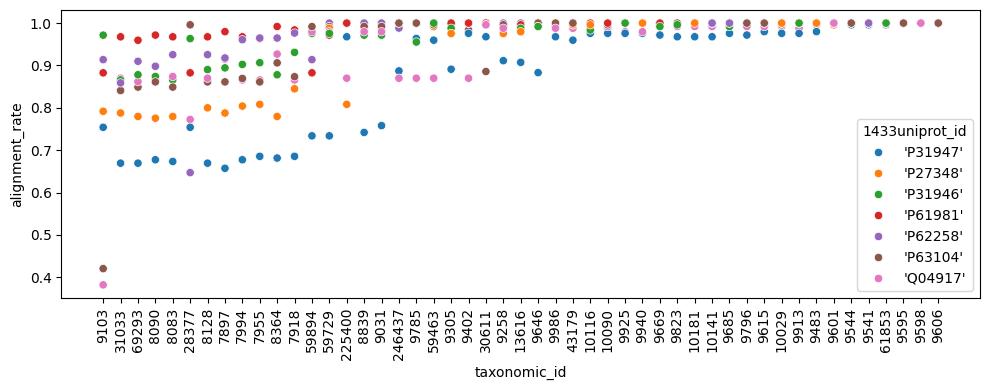

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate mean alignment rate for each taxonomic_id and sort
avg_by_taxid = merged_df.groupby('taxonomic_id')['alignment_rate'].mean().sort_values()
sorted_taxids = avg_by_taxid.index

# Create a new dataframe with sorted taxonomic_ids
merged_df_sorted = merged_df.copy()
merged_df_sorted['taxonomic_id'] = pd.Categorical(merged_df_sorted['taxonomic_id'], 
                                                categories=sorted_taxids, 
                                                ordered=True)
merged_df_sorted = merged_df_sorted.sort_values('taxonomic_id')

# Create the plot
plt.figure(figsize=(10, 4))
sns.scatterplot(data=merged_df_sorted, 
                x='taxonomic_id', 
                y='alignment_rate', 
                hue='1433uniprot_id')

plt.xticks(rotation=90, fontsize=10)
plt.xlabel('taxonomic_id')
plt.ylabel('alignment_rate')
plt.title('')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [23]:
merged_df_sorted.head(2)

,1433uniprot_id,taxonomic_id,e_value,identity length,alignment length,protein_length,alignment pair,alignment_rate
247,'P31947',9103,8.85145e-135,187,246,248,'P31947'_9103,0.754032
245,'P27348',9103,2.3004e-148,194,245,245,'P27348'_9103,0.791837


In [24]:
# drop 9103, use the remaining species as the species for augmentation
sampling_species_lst = set(merged_df_sorted["taxonomic_id"])
sampling_species_lst.remove("9103")

In [25]:
len(sampling_species_lst)

48

In [26]:
# sampling_species_lst

Task 32: we extracted homologous (RBH) 14-3-3 binding proteins and their isoforms from the UniRef90 database from 48 species (human included).

In [28]:
### Download all homologous sequences for a given protein UniProt ID within a specified list of species.

In [29]:
# install Blast+
# https://blast.ncbi.nlm.nih.gov/doc/blast-help/downloadblastdata.html#downloadblastdata

In [30]:
# https://ftp.uniprot.org/pub/databases/uniprot/current_release/uniref/uniref90/
# download uniref90
# build db uniref90 for blast search and retrieve

In [31]:
# filter_fasta_by_taxid
# from Bio import SeqIO

# # Define the list of TaxIDs you want to filter by
# taxid_list = sampling_species_lst 

# # Input and output FASTA file paths
# input_fasta = "../Downloads/uniref90.fasta"
# output_fasta = "data/filtered_uniref90.fasta"

# def filter_fasta_by_taxid(input_fasta, output_fasta, taxid_list):
#     count_no_taxid = 0  # Counter for records without TaxID info
#     count_invalid_taxid = 0  # Counter for records with invalid TaxID info

#     with open(output_fasta, "w") as out_file:
#         for record in SeqIO.parse(input_fasta, "fasta"):
#             header = record.description
#             parts = header.split('TaxID=')
#             if len(parts) > 1:
#                 taxid_part = parts[1]
#                 taxid_split = taxid_part.split()
#                 if taxid_split:
#                     try:
#                         taxid = str(taxid_split[0])
#                         if taxid in taxid_list:
#                             SeqIO.write(record, out_file, "fasta")
#                     except ValueError:
#                         count_invalid_taxid += 1
#                 else:
#                     count_no_taxid += 1
#             else:
#                 count_no_taxid += 1

#     # Report the count of records without TaxID information
#     print(f"Number of records without TaxID information: {count_no_taxid}")
#     print(f"Number of records with invalid TaxID information: {count_invalid_taxid}")

# # Run the filtering function
# filter_fasta_by_taxid(input_fasta, output_fasta, taxid_list)

In [32]:
# build db uniref90-48 for blast search and retrieve

In [33]:
# build db human-reviewed for blast search and retrieve

In [34]:
import os
import requests
from Bio.Blast.Applications import NcbiblastpCommandline
from Bio.Blast import NCBIXML
import re
def perform_blast_human(sequence, db, target_species, output_file='blast_result_human.xml'):
    """Perform a BLAST search using local BLAST and return the best hit for the target species."""
    with open("query_human.fasta", "w") as f:
        f.write(sequence)
    
    # Specify the full path to the blastp executable
    blastp_path = "/Users/newuser/ncbi-blast-2.16.0+/bin/blastp" 

    blastp_cline = NcbiblastpCommandline(cmd=blastp_path, query="query_human.fasta", db=db, evalue=0.001, outfmt=5, out=output_file)
    
    # Run BLASTP and capture stdout and stderr
    stdout, stderr = blastp_cline()
    
    with open(output_file) as result_handle:
        blast_records = NCBIXML.read(result_handle)
    
    for alignment in blast_records.alignments:
        hit_id = alignment.hit_id
        hit_def = alignment.hit_def
        # print(f"Checking hit {hit_id}: {hit_def}")  # Debug output
        uniprot_id, species = get_species_uniprot_id_human(hit_def)
        if species == target_species:
            return alignment
    
    return None

def get_species_uniprot_id_human(hit_def):
    """
    Extract UniProt ID and taxonomy ID from the hit definition string.
    Assumes hit_def follows the format: 'sp|UniProtID|Description OS=Species OX=TaxID ...'.
    """
    parts = hit_def.split('|')
    
    if len(parts) < 3:
        return None, None

    uniprot_id = parts[1]
    
    # Extract taxonomy ID
    match = re.search(r'OX=(\d+) ', hit_def)
    if match:
        taxid = match.group(1)
    else:
        taxid = None
    return uniprot_id, taxid

# Example usage:
sequence = "MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNLLHVDFQNTPYCFDQLRRRFGDVFSLQLAWTPVVVLNGLAAVREAMVTRGEDTADRPPAPIYQVLGFGPRSQGVILSRYGPAWREQRRFSVSTLRNLGLGKKSLEQWVTEEAACLCAAFADQAGRPFRPNGLLDK"
human_db = "/Users/newuser/blastdb/human-reviewed"
target_species = "9606"
perform_blast_human(sequence, human_db, target_species)

In [35]:
import requests
import xml.etree.ElementTree as ET

def get_isoforms(uniprot_id):
    """Fetch isoforms for a given UniProt ID."""
    base_url = f"https://www.ebi.ac.uk/proteins/api/proteins/{uniprot_id}/isoforms"
    print(base_url)
    response = requests.get(base_url)
    if response.status_code != 200:
        # raise Exception(f"Failed to fetch isoforms for {uniprot_id} from UniProt.")
        return [uniprot_id]

    root = ET.fromstring(response.content)
    namespace = {'uniprot': 'http://uniprot.org/uniprot'}
    
    isoforms = []
    for isoform in root.findall('.//uniprot:isoform', namespaces=namespace):
        isoform_id = isoform.find('uniprot:id', namespaces=namespace).text
        isoforms.append(isoform_id)
    
    return list(set(isoforms + [uniprot_id]))

# # Example usage
# uniprot_id = "Q06413"
# isoforms = get_isoforms(uniprot_id)
# print(isoforms)

In [36]:
import os
import requests
from Bio.Blast.Applications import NcbiblastpCommandline
from Bio.Blast import NCBIXML
import re

# Define a dictionary to hold sequences locally
sequence_dict = {}

def fetch_sequence(uniprot_id):
    # Check if the sequence is already stored locally
    if uniprot_id in sequence_dict:
        print(f"Sequence for {uniprot_id} is already available locally.")
        return sequence_dict[uniprot_id]      
    
    # Check if the sequence is already stored locally in the uniref90 dictionary  
    """Fetch the protein sequence from local dictionary given a UniProt ID."""
    sequence = uniref90_48_dict.get(uniprot_id, None)
    
    if sequence:
        return sequence

    """Fetch the protein sequence from UniProt given a UniProt ID."""

    # If not locally available, fetch from UniProt
    sequence_url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    response = requests.get(sequence_url)
    if response.status_code != 200:
        print(f"Failed to retrieve sequence for {uniprot_id}")
        return None
        
    fasta_text = response.text.strip()
    
    if not fasta_text.startswith('>'):
        print(f"Sequence retrieved for {uniprot_id} is not in FASTA format.")
        return None
    
    lines = fasta_text.split('\n')
    sequence = ''.join(lines[1:])  # return the full FASTA format for use with BLAST
    # Save the fetched sequence into the dictionary
    sequence_dict[uniprot_id] = sequence
    print(f"Fetched sequence for {uniprot_id}:\n")
    return sequence


def perform_blast(sequence, db, target_species_lst, output_file='blast_result.xml'):
    """Perform a BLAST search using local BLAST and return the best hit for the target species."""
    with open("query.fasta", "w") as f:
        f.write(sequence)
    
    # Specify the full path to the blastp executable
    blastp_path = "/Users/newuser/ncbi-blast-2.16.0+/bin/blastp"  # Update this with the actual path to blastp on your system

    blastp_cline = NcbiblastpCommandline(cmd=blastp_path, query="query.fasta", db=db, evalue=0.001, outfmt=5, out=output_file)
    
    # Run BLASTP and capture stdout and stderr
    stdout, stderr = blastp_cline()
    # print(f"stdout: {stdout}")
    # print(f"stderr: {stderr}")
    
    with open(output_file) as result_handle:
        blast_records = NCBIXML.read(result_handle)
        
    uniprot_id_lst = []
    target_species_set = set(target_species_lst)
    
    for alignment in blast_records.alignments:
        hit_id = alignment.hit_id
        hit_def = alignment.hit_def
        # print(f"Checking hit {hit_id}: {hit_def}")  # Debug output
        uniprot_id, species = get_species_uniprot_id(hit_def)
        if species in target_species_set:
            uniprot_id_lst.append(uniprot_id)
            target_species_set.discard(species)
    
    return uniprot_id_lst


def get_species_uniprot_id(hit_def):
    """
    Extract UniProt ID and species from the hit_def.
    
    Example hit_def: 'Serum response factor n=1 Tax=Latimeria chalumnae TaxID=7897 RepID=H3B378_LATCH'
    """
    
    # Extract UniProt ID using a regular expression
    uniprot_match = re.search(r'UniRef90_([\w-]+)', hit_def)
    uniprot_id = uniprot_match.group(1) if uniprot_match else None
    
    # Extract species ID using a regular expression
    species_match = re.search(r'TaxID=(\d+)', hit_def)
    species_id = species_match.group(1) if species_match else None
    
    # Debug print
    # print(f"Extracted UniProt ID: {uniprot_id}, Species: {species_id}")
    
    return uniprot_id, species_id

def reciprocal_blast(uniprot_id, target_species_lst, species_db, original_db):
    """Perform RBH to find orthologs using local BLAST for a given uniprot_id and target_species_lst."""
    # Fetch sequence for the given UniProt ID
    query_sequence = fetch_sequence(uniprot_id)

    if not query_sequence:
        return None
    
    # 1. BLAST query sequence against species target proteome
    # return a target_hit_lst which contain the first target hit for each species
    target_hit_lst = perform_blast(query_sequence, species_db, target_species_lst)
    if target_hit_lst:
        print(f"Initial BLAST target hit: {target_hit_lst}")
    else:
        print(f"No target hit found in first BLAST search for {uniprot_id}.")
        return None
    
#     # Extract UniProt ID from target_hit definition
#     target_uniprot_id, _ = get_species_uniprot_id(target_hit.hit_def)
#     print(target_uniprot_id)
    
    RBH_lst = [uniprot_id]
    # Fetch sequence for the target hit
    for target_uniprot_id in target_hit_lst:
            
        target_sequence = fetch_sequence(target_uniprot_id)
    
        if not target_sequence:
            continue
    
        # 2. BLAST target hit sequence back to the original species proteome
        original_hit = perform_blast_human(target_sequence, original_db, "9606")
        if original_hit:
            print(f"Reciprocal BLAST original hit: {original_hit.hit_def}")
        else:
            print(f"No original hit found in second BLAST search for {target_uniprot_id}.")
            continue
    
        # Get UniProt ID from original hit title
        original_best_hit_id, _ = get_species_uniprot_id_human(original_hit.hit_def)
    
        # Check if the original query UniProt ID matches the best hit ID
        if uniprot_id == original_best_hit_id:
            RBH_lst.append(target_uniprot_id)
        else:
            continue
    return RBH_lst

# Example usage
uniprot_id = "Q06413-3"
target_species = "10090"  # Change this to the desired species you are looking for
species_db = "/Users/newuser/blastdb/uniref90-48"  # Absolute path to the species BLAST database
original_db = "/Users/newuser/blastdb/human-reviewed"  # Absolute path to the original species BLAST database (e.g., human proteome)

# try:
#     ortholog_id = reciprocal_blast(uniprot_id, target_species, species_db, original_db)
#     if ortholog_id:
#         print(f"Ortholog or best hit found from species {target_species}: {ortholog_id}")
#     else:
#         print("No hit found.")
# except Exception as e:
#     print(f"Error: {str(e)}")

In [37]:
get_species_uniprot_id(">UniRef90_P11362-16 Isoform 17 of Fibroblast growth factor receptor 1 n=3 Tax=Homo sapiens TaxID=9606 RepID=P11362-16")

('P11362-16', '9606')

In [38]:
# build the uniref90_48_dict
from Bio import SeqIO

def parse_fasta(file_path):
    fasta_dict = {}
    for record in SeqIO.parse(file_path, "fasta"):
        # Extract the Uniprot ID from the description line
        # Typically, the Uniprot ID is the first part of the description by '|' delimiter
        # For headers like ">sp|P12345|... description", use the second part:
        record_id = record.id
        uniprot_id, _ = get_species_uniprot_id(record_id)
        # print(uniprot_id)
        # print(record.seq)
        
        # Add to dictionary
        fasta_dict[uniprot_id] = str(record.seq)
    
    return fasta_dict

# Example usage:
file_path = '/Users/newuser/Downloads/filtered_uniref90.fasta'
uniref90_48_dict = parse_fasta(file_path)
len(uniref90_48_dict)

714079

In [39]:
import requests
from Bio import SeqIO
from io import StringIO

def download_all_homologs(uniprot_id, species_list):

    # Get homologous sequences for each isoform and the original UniProt ID
    print(f"Fetching homologous sequences for {uniprot_id}")
    all_homologs = reciprocal_blast(uniprot_id, species_list, species_db, original_db)    
    print(f"Number of homologous sequences for {uniprot_id}: {len(all_homologs)}")

    return all_homologs

def download_all_isoforms(query_uniprot_id, species_list):
    
    uniprot_id_reciprocal_blast_lst = download_all_homologs(query_uniprot_id, species_list)

    all_homologs = []
    for uniprot_id in uniprot_id_reciprocal_blast_lst:
        isoforms = get_isoforms(uniprot_id)
        print(f"Number of isoforms found for {uniprot_id}: {len(isoforms)}")
        all_homologs += isoforms
    print(f"Number of homologous and isoforms found for {query_uniprot_id}: {len(set(all_homologs))}")
    return set(all_homologs)
        

# Example usage
uniprot_id = "Q06413"
species_list = ["10090", '225400', '246437',"9606"]  # Human (Homo sapiens), Mouse (Mus musculus)
all_homologs = download_all_isoforms(uniprot_id, species_list)

print(set(all_homologs))

Fetching homologous sequences for Q06413
Fetched sequence for Q06413:

Initial BLAST target hit: ['Q8CFN5', 'L9JAJ5', 'L5LDA9', 'Q5IRN4']
Reciprocal BLAST original hit: sp|Q06413|MEF2C_HUMAN Myocyte-specific enhancer factor 2C OS=Homo sapiens OX=9606 GN=MEF2C PE=1 SV=1
Reciprocal BLAST original hit: sp|Q02078|MEF2A_HUMAN Myocyte-specific enhancer factor 2A OS=Homo sapiens OX=9606 GN=MEF2A PE=1 SV=1
Reciprocal BLAST original hit: sp|Q02078|MEF2A_HUMAN Myocyte-specific enhancer factor 2A OS=Homo sapiens OX=9606 GN=MEF2A PE=1 SV=1
Reciprocal BLAST original hit: sp|Q96EP5|DAZP1_HUMAN DAZ-associated protein 1 OS=Homo sapiens OX=9606 GN=DAZAP1 PE=1 SV=1
Number of homologous sequences for Q06413: 2
https://www.ebi.ac.uk/proteins/api/proteins/Q06413/isoforms
Number of isoforms found for Q06413: 7
https://www.ebi.ac.uk/proteins/api/proteins/Q8CFN5/isoforms
Number of isoforms found for Q8CFN5: 6
Number of homologous and isoforms found for Q06413: 13
{'Q8CFN5-2', 'Q8CFN5-4', 'Q8CFN5', 'Q06413-1',

In [37]:
# for each uniprot id in table1, find all the homologies and save it into a list
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df = curated_dataset_df[curated_dataset_df["label"]==1]
positive_protein_lst = set(curated_dataset_df["human homology accession"])
print(len(positive_protein_lst))
positive_protein_lst

288


{'A0AVK6',
 'A2RUS2',
 'A7KAX9',
 'O00159',
 'O14558',
 'O14727',
 'O14757',
 'O14974',
 'O15151',
 'O15516',
 'O15530',
 'O15553',
 'O43314',
 'O43524',
 'O43566',
 'O43791',
 'O43896',
 'O60343',
 'O60741',
 'O60825',
 'O75030',
 'O75376',
 'O75385',
 'O75628',
 'O75791',
 'O76090',
 'O94827',
 'O94875',
 'O94885',
 'O94921',
 'O94988',
 'O95382',
 'O95863',
 'O96013',
 'P00338',
 'P00519',
 'P03372',
 'P04049',
 'P04150',
 'P04233',
 'P04637',
 'P05107',
 'P05114',
 'P05783',
 'P07101',
 'P07359',
 'P07954',
 'P08069',
 'P08151',
 'P10070',
 'P10071',
 'P10275',
 'P10636',
 'P11362',
 'P13569',
 'P14136',
 'P15056',
 'P15144',
 'P16333',
 'P16471',
 'P17302',
 'P17752',
 'P18615',
 'P19484',
 'P19634',
 'P20701',
 'P20941',
 'P21127',
 'P21802',
 'P21980',
 'P22736',
 'P23528',
 'P26045',
 'P26358',
 'P26651',
 'P27986',
 'P30291',
 'P30304',
 'P30305',
 'P30307',
 'P32004',
 'P32927',
 'P35222',
 'P35568',
 'P40818',
 'P41181',
 'P41279',
 'P42575',
 'P43405',
 'P43681',
 'P46527',

In [38]:
homology_dict = {}

In [46]:
for i, uniprot_id in enumerate(positive_protein_lst):
    print(i)
    
    # Check if the CSV file exists
    csv_file = "data/homologs.csv"
    if os.path.isfile(csv_file) and os.path.getsize(csv_file) > 0:
        # Read the CSV file into a DataFrame if it exists and is not empty
        df = pd.read_csv(csv_file)
    
        # If 'Homologs' column contains lists stored as strings, convert them back to lists
        if 'Homologs' in df.columns:
            df['Homologs'] = df['Homologs'].apply(eval)
    else:
        # Initialize an empty DataFrame with the specified columns if the file does not exist or is empty
        df = pd.DataFrame(columns=['UniprotID', 'Homologs'])
        
    if uniprot_id in list(df['UniprotID']):
        continue
    else:
        homology_dict = dict(zip(df['UniprotID'], df['Homologs']))
        all_homologs = download_all_isoforms(uniprot_id, sampling_species_lst)
        homology_dict[uniprot_id] = all_homologs
        homology_df = pd.DataFrame(list(homology_dict.items()), columns=['UniprotID', 'Homologs'])
        homology_df.to_csv(csv_file)

    
homology_df = pd.DataFrame(list(homology_dict.items()), columns=['UniprotID', 'Homologs'])
homology_df.to_csv("data/homologs_all.csv")
homology_df

0
Fetching homologous sequences for Q9UPN4
Fetched sequence for Q9UPN4:

Initial BLAST target hit: ['Q9UPN4-2', 'K7BRX3', 'UPI00300813B6', 'UPI00122D78AD', 'A0A2K5VXY7', 'A0A5F4W1J7', 'A0A9J7JW99', 'G5BJ59', 'A0A8D1LRY6', 'L9KZJ7', 'A0A8C0PRS2', 'UPI0011AF8A53', 'H3AZA8', 'UPI0007AD8B2E', 'W5N5R0', 'A0A2J8Y2G8', 'A0A3B1JT43', 'M1EF84', 'A0A493SUC6', 'UPI000D534209', 'H2S8V1', 'A0A3B3I396', 'UPI0019D41872']
Reciprocal BLAST original hit: sp|Q9UPN4|CP131_HUMAN Centrosomal protein of 131 kDa OS=Homo sapiens OX=9606 GN=CEP131 PE=1 SV=3
Reciprocal BLAST original hit: sp|Q9UPN4|CP131_HUMAN Centrosomal protein of 131 kDa OS=Homo sapiens OX=9606 GN=CEP131 PE=1 SV=3
Reciprocal BLAST original hit: sp|Q9UPN4|CP131_HUMAN Centrosomal protein of 131 kDa OS=Homo sapiens OX=9606 GN=CEP131 PE=1 SV=3
Reciprocal BLAST original hit: sp|Q9UPN4|CP131_HUMAN Centrosomal protein of 131 kDa OS=Homo sapiens OX=9606 GN=CEP131 PE=1 SV=3
Reciprocal BLAST original hit: sp|Q9UPN4|CP131_HUMAN Centrosomal protein of 13

,UniprotID,Homologs
0,Q9UPN4,"{A0A8C0PRS2, Q9UPN4-3, Q9UPN4, W5N5R0, A0A5F4W..."
1,Q86V87,"{Q86V87, F7CAU0, A0A9L0R7K1, A0A8B9RHJ5, A0A80..."
2,Q16613,"{UPI000FFB821D, A0AAJ7KVD3, Q16613, A0A3B3IDJ9..."
3,Q92974,"{UPI0029525EDD, A0A8C2NDQ1, Q92974, A0A287APM0..."
4,Q9UJM3,"{G5C550, W5M8M5, Q9UJM3, UPI002F2B3C87, A0A8B9..."
...,...,...
283,O15530,"{O15530-3, H2R0W1, E9PER6, A0AAJ7JLP0, A0A6I8N..."
284,Q5VWQ8,"{F6TDB7, UPI001D19D3CC, G1L1W5, A0A5G2Q9F3, W5..."
285,Q9UQL6,"{Q9UQL6-1, A0AAJ7P6V6, Q9UQL6-2, Q9UQL6-3, UPI..."
286,Q15942,"{A0A3P9HSV1, G3P7U0, A0A7N5J946, A0A061IK90, Q..."


In [47]:
homology_df.to_csv("homologs_all.csv")

In [48]:
homology_df.to_csv("data/homologs_all.csv")

In [49]:
csv_file = 'data/homologs_all.csv'
df = pd.read_csv(csv_file)
df.head()

,Unnamed: 0,UniprotID,Homologs
0,0,Q9UPN4,"{'A0A8C0PRS2', 'Q9UPN4-3', 'Q9UPN4', 'W5N5R0',..."
1,1,Q86V87,"{'Q86V87', 'F7CAU0', 'A0A9L0R7K1', 'A0A8B9RHJ5..."
2,2,Q16613,"{'UPI000FFB821D', 'A0AAJ7KVD3', 'Q16613', 'A0A..."
3,3,Q92974,"{'UPI0029525EDD', 'A0A8C2NDQ1', 'Q92974', 'A0A..."
4,4,Q9UJM3,"{'G5C550', 'W5M8M5', 'Q9UJM3', 'UPI002F2B3C87'..."
...,...,...,...
283,283,O15530,"{'O15530-3', 'H2R0W1', 'E9PER6', 'A0AAJ7JLP0',..."
284,284,Q5VWQ8,"{'F6TDB7', 'UPI001D19D3CC', 'G1L1W5', 'A0A5G2Q..."
285,285,Q9UQL6,"{'Q9UQL6-1', 'A0AAJ7P6V6', 'Q9UQL6-2', 'Q9UQL6..."
286,286,Q15942,"{'A0A3P9HSV1', 'G3P7U0', 'A0A7N5J946', 'A0A061..."


In [50]:
### Ensure that the multiple sequence alignment (MSA) has serine (S) or threonine (T) at the corresponding positions.

# Read the input sequences from a FASTA file.
# Perform multiple sequence alignment (MSA).
# Check at the given site whether all the sequences have S or T.
# Return the aligned sequences where the given site has S or T.

In [51]:
# base on the homologs_all.csv file
# build the fasta file for each uniprot id
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

csv_file = 'data/homologs_all.csv'
df = pd.read_csv(csv_file)
df
# Process each row in the dataframe
for idx, row in df.iterrows():
    uniprot_id = row['UniprotID']
    homologs = eval(row['Homologs'])  # Convert the string representation of the set back to a set
    # Remove uniprot_id from the homologs if it's in the set
    if uniprot_id in homologs:
        homologs.remove(uniprot_id)
    
    # Create a new list for nomology with uniprot_id as the first element
    homologs = [uniprot_id] + list(homologs)
    # print(homologs)

    # Prepare the sequence records for the FASTA file
    seq_records = []
    for homolog in homologs:
        sequence = fetch_sequence(homolog)
        if sequence:
            sequence = sequence.strip().replace('\n', '').replace('\r', '')  
            seq_record = SeqRecord(Seq(sequence), id=homolog, description="")
            seq_records.append(seq_record)
    # print(seq_records)
        
    output_directory = "data/homology/"
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
    # Write the sequences to the FASTA file with the filename as the UniProt ID
    fasta_filename = os.path.join(output_directory, f"{uniprot_id}_homology.fasta")
    with open(fasta_filename, 'w') as output_handle:
        SeqIO.write(seq_records, output_handle, 'fasta')

    print(f"Saved {fasta_filename}")

print("Completed processing all rows.")

Sequence for Q9UPN4 is already available locally.
Fetched sequence for Q9UPN4-1:

Saved data/homology/Q9UPN4_homology.fasta
Sequence for Q86V87 is already available locally.
Sequence for A0A803TN10 is already available locally.
Sequence for R0J7Q9 is already available locally.
Saved data/homology/Q86V87_homology.fasta
Sequence for Q16613 is already available locally.
Fetched sequence for Q16613-2:

Fetched sequence for Q16613-1:

Sequence for Q9H3S9 is already available locally.
Saved data/homology/Q16613_homology.fasta
Sequence for Q92974 is already available locally.
Fetched sequence for Q92974-3:

Fetched sequence for Q92974-2:

Fetched sequence for Q92974-1:

Saved data/homology/Q92974_homology.fasta
Sequence for Q9UJM3 is already available locally.
Sequence for A0A5F5PT97 is already available locally.
Saved data/homology/Q9UJM3_homology.fasta
Sequence for P48552 is already available locally.
Saved data/homology/P48552_homology.fasta
Sequence for Q8IYK8 is already available locally

In [52]:
sequence_dict["Q15831-2"]

'MEVVDPQQLGMFTEGELMSVGMDTFIHRIDSTEVIYQPRRKRAKLIGKYLMGDLLGEGSYGKVKEVLDSETLCRRAVKILKKKKLRRIPNGEANVKKEIQLLRRLRHKNVIQLVDVLYNEEKQKMYMVMEYCVCGMQEMLDSVPEKRFPVCQAHGYFCQLIDGLEYLHSQGIVHKDIKPGNLLLTTGGTLKISDLGVAEALHPFAADDTCRTSQGSPAFQPPEIANGLDTFSGFKVDIWSAGVTLYNITTGLYPFEGDNIYKLFENIGKGSYAIPGDCGPPLSDLLKGMLEYEPAKRFSIRQIRQHSWFRKKHPPAEAPVPIPPSPDTKDRWRSMTVVPYLEDLHGADEDEDLFDIEDDIIYTQDFTVPGGEEASEAGLRAERGLQKSEGSDLSGEEASRPAPQ'

In [40]:
from Bio import SeqIO, AlignIO
from Bio.Align import MultipleSeqAlignment
from Bio.Align.Applications import ClustalOmegaCommandline
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import os

# def create_sample_fasta(file_name):
#     # Create a sample FASTA file
#     sequences = [
#         SeqRecord(Seq("MAGTFLILTPSQLRVASETTPANYIDSDTQQNLWIIRGVGHDSPHIVKDQMRE"), id="seq1"),
#         SeqRecord(Seq("MAGTFILLTPTSAQLRVASDTTPANYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGYGHDSPHIVKDQMRE"), id="seq2"),
#         SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq3"),
#     ]
#     SeqIO.write(sequences, file_name, "fasta")

def perform_msa(input_fasta, clustalomega_path):
    # Perform MSA using Clustal Omega
    records = list(SeqIO.parse(input_fasta, "fasta"))
    if len(records) <=1:
        alignment = AlignIO.read(input_fasta, "fasta")
        return alignment
    
    clustalomega_cline = ClustalOmegaCommandline(cmd=clustalomega_path, infile=input_fasta, outfile="aligned_sequences.fasta", force=True, verbose=True)
    stdout, stderr = clustalomega_cline()
    
    # Read the aligned sequences
    alignment = AlignIO.read("aligned_sequences.fasta", "fasta")
    return alignment

def map_original_index_to_aligned_index(aligned_seq, original_seq, original_index):
    """
    Map the original index to the corresponding index in the aligned sequence.
    """
    aligned_index = -1
    original_counter = 0

    for i, res in enumerate(aligned_seq):
        if res != '-':
            if original_counter == original_index:
                aligned_index = i
                break
            original_counter += 1

    return aligned_index

def check_site(alignment, original_index, site_residue, original_seq):
    aligned_seq = alignment[0].seq  # assuming the first sequence is the reference sequence
    aligned_index = map_original_index_to_aligned_index(aligned_seq, original_seq, original_index)
    if aligned_index == -1:
        raise ValueError("Failed to map original index to aligned index")

    sequences_with_s_t = []
    for record in alignment:
        if record.seq[aligned_index] in site_residue:
            sequences_with_s_t.append(record)
    return MultipleSeqAlignment(sequences_with_s_t)

def filtered_site_alignment(uniprot_id, original_index):
    sample_fasta = f"data/homology/{uniprot_id}_homology.fasta"
    clustalomega_path = "/Users/newuser/clustalo" # mac
    # clustalomega_path = "C:/Users/LuVul/clustal-omega-1.2.2-win64/clustalo.exe" # windows

    
    # read the first seq as original_seq
    records = list(SeqIO.parse(sample_fasta, "fasta"))
    original_seq = records[0].seq
    
    # Perform multiple sequence alignment
    alignment = perform_msa(sample_fasta, clustalomega_path)
    print(alignment)
    
    # Retrieve the residue at original index in the aligned sequence
    original_site_residue = original_seq[original_index] # Suppose during real alignment this might change

    # Check and return sequences with the same residue in the specified index
    filtered_alignment = check_site(alignment, original_index, original_site_residue, original_seq)
    print(filtered_alignment)

    output_directory = "data/filtered_alignment/"
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
        
    # Save the filtered alignment to a new FASTA file
    with open(f"data/filtered_alignment/filtered_alignment_{uniprot_id}_{original_index}.fasta", "w") as output_fasta:
        SeqIO.write(filtered_alignment, output_fasta, "fasta")
    print(f"Filtered aligned sequences have been written to 'filtered_alignment_{uniprot_id}_{original_index}.fasta'.")

# Execute main function
# filtered_site_alignment()

In [60]:
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df = curated_dataset_df[curated_dataset_df["label"]==1]
curated_dataset_df.head()

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461
2,P98177,32,T32t,1,20141511
3,P14136,8,S8s,1,20141511
4,P08151,640,S640s,1,20141511
...,...,...,...,...,...
781,Q53ET0,368,S368s,1,18626018
782,Q05086-2,485,T485t,1,28835500
783,P40818,718,S718s/S716A,1,17720156
784,P40818,718,S718s,1,17720156


In [61]:
for idx, row in curated_dataset_df.iterrows():
    uniprot_id = row['human homology accession']
    site_idx = int(row['human homology site without letter'])-1
    print(idx, uniprot_id, site_idx)
    output_csv = f"data/filtered_alignment/filtered_alignment_{uniprot_id}_{site_idx}.fasta"
    if os.path.isfile(output_csv):
        print(f"{output_csv} File exists")
        continue
    filtered_site_alignment(uniprot_id, site_idx)

0 P43681 466
data/filtered_alignment/filtered_alignment_P43681_466.fasta File exists
1 P11362 778
data/filtered_alignment/filtered_alignment_P11362_778.fasta File exists
2 P98177 31
data/filtered_alignment/filtered_alignment_P98177_31.fasta File exists
3 P14136 7
data/filtered_alignment/filtered_alignment_P14136_7.fasta File exists
4 P08151 639
data/filtered_alignment/filtered_alignment_P08151_639.fasta File exists
5 P10070 969
data/filtered_alignment/filtered_alignment_P10070_969.fasta File exists
6 P10071 1005
data/filtered_alignment/filtered_alignment_P10071_1005.fasta File exists
7 Q13322 427
data/filtered_alignment/filtered_alignment_Q13322_427.fasta File exists
8 Q8WUI4 357
data/filtered_alignment/filtered_alignment_Q8WUI4_357.fasta File exists
9 P04233 7
data/filtered_alignment/filtered_alignment_P04233_7.fasta File exists
10 P08069 1312
data/filtered_alignment/filtered_alignment_P08069_1312.fasta File exists
11 Q9UK53 341
data/filtered_alignment/filtered_alignment_Q9UK53_341.fa

In [62]:
### Use MMseqs2 to cluster the remaining sequences and select a seed sequence from each cluster.
### Use a prediction tool to ensure the target site can bind 14-3-3 proteins.

In [63]:
#install mmseqs2
#brew install mmseqs2

In [41]:
import os
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import pandas as pd

# Function to create a sample FASTA file
def create_sample_fasta(file_name):
    sequences = [
        SeqRecord(Seq("MAGTFILLTPSQLRVASETTPANYIDSDTQQNLWIIRGVGHDSPHIVKDQMRE"), id="seq1"),
        SeqRecord(Seq("MAGTFILLTPTSAQLRVASDTTPANYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGYGHDSPHIVKDQMRE"), id="seq2"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq3"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGK"), id="seq4"),
        SeqRecord(Seq("FFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq5"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIRGVGHDSPSIVKDQMRE"), id="seq6"),
        SeqRecord(Seq("MAGTDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq7"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGDQMRE"), id="seq8"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq9"),
        # Add more sequences as needed
    ]
    SeqIO.write(sequences, file_name, "fasta")

# Create a sample FASTA file
sample_fasta = "sample_sequences.fasta"
create_sample_fasta(sample_fasta)

# Define MMseqs2 paths and commands
mmseqs2_bin = r"C:\Users\LuVul\mmseqs\mmseqs.bat"  

# Define output prefix and temporary directory
output_prefix = "assembly_clustered"
tmp_dir = "tmp"


similarity = 0.9

!{mmseqs2_bin} easy-cluster {sample_fasta} {output_prefix} {tmp_dir} --min-seq-id {similarity}

from Bio import SeqIO

def clean_fasta(input_file, output_file):
    with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
        fasta_sequences = SeqIO.parse(infile, 'fasta')
        
        for record in fasta_sequences:
            # Remove hyphens from the sequence
            cleaned_seq = str(record.seq).replace('-', '')
            
            # Update the sequence of the record
            record.seq = cleaned_seq
            
            # Write the cleaned record to the output file
            SeqIO.write(record, outfile, 'fasta')


def select_representation_sequence(uniprot_id, site, similarity):
    filtered_alignment_fasta = f"data/filtered_alignment/filtered_alignment_{uniprot_id}_{site}.fasta"
    cleaned_fasta = f"data/cleaned/{uniprot_id}_{site}.fasta"

    if not os.path.exists("data/cleaned/"):
        os.makedirs("data/cleaned/")

    if not os.path.exists("data/assembly_clustered/"):
        os.makedirs("data/assembly_clustered/")
    
    # rebuild the filtered_alignment fasta file, remove all the -------------- in it
    clean_fasta(filtered_alignment_fasta, cleaned_fasta)

    # Define MMseqs2 paths and commands
    # mmseqs2_bin = r"C:\Users\LuVul\mmseqs\mmseqs.bat" # windows
    mmseqs2_bin = "/usr/local/bin/mmseqs" # mac

    # Define output prefix and temporary directory
    output_prefix = f"data/assembly_clustered/assembly_clustered_{uniprot_id}_{site}"
    tmp_dir = "tmp"

    similarity = similarity
    print(f"{mmseqs2_bin} easy-cluster {cleaned_fasta} {output_prefix} {tmp_dir} --min-seq-id {similarity}")
    !{mmseqs2_bin} easy-cluster {cleaned_fasta} {output_prefix} {tmp_dir} --min-seq-id {similarity}


# # Load and display results
# results_file = f"sample_search.tsv"
# df = pd.read_csv(results_file, sep='\t', header=None)
# print(df.head())

/bin/bash: C:UsersLuVulmmseqsmmseqs.bat: command not found


In [60]:
select_representation_sequence("P43681", 466, 0.85)

/usr/local/bin/mmseqs easy-cluster data/cleaned/P43681_466.fasta data/assembly_clustered/assembly_clustered_P43681_466 tmp --min-seq-id 0.85
easy-cluster data/cleaned/P43681_466.fasta data/assembly_clustered/assembly_clustered_P43681_466 tmp --min-seq-id 0.85 

MMseqs Version:                     	16-747c6
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.8
Coverage mode                       	0
Compositional bias               

/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/Bio/SeqRecord.py:354: BiopythonDeprecationWarning: Using a string as the sequence is deprecated and will raise a TypeError in future. It has been converted to a Seq object.
  warnings.warn(


createdb data/cleaned/P43681_466.fasta tmp/17701556506352501312/input --dbtype 0 --shuffle 1 --createdb-mode 1 --write-lookup 0 --id-offset 0 --compressed 0 -v 3 

Shuffle database cannot be combined with --createdb-mode 0
We recompute with --shuffle 0
Converting sequences
Multiline fasta can not be combined with --createdb-mode 0
We recompute with --createdb-mode 1
Time for merging to input_h: 0h 0m 0s 1ms
Time for merging to input: 0h 0m 0s 0ms

Time for merging to input_h: 0h 0m 0s 0ms
Time for merging to input: 0h 0m 0s 0ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 5ms
Create directory tmp/17701556506352501312/clu_tmp
cluster tmp/17701556506352501312/input tmp/17701556506352501312/clu tmp/17701556506352501312/clu_tmp --max-seqs 20 -c 0.8 --spaced-kmer-mode 1 --alignment-mode 3 -e 0.001 --min-seq-id 0.85 --remove-tmp-files 1 

Set cluster sensitivity to -s 1.000000
Set cluster mode SET COVER
Set cluster iterations to 1
linclust tmp/17701556506352501312/input tmp/1770155

In [ ]:
for idx, row in curated_dataset_df.iterrows():
    uniprot_id = row['human homology accession']
    site_idx = int(row['human homology site without letter'])-1
    print(idx, uniprot_id, site_idx)
    select_representation_sequence(uniprot_id, site_idx, 0.85)

0 P43681 466
/usr/local/bin/mmseqs easy-cluster data/cleaned/P43681_466.fasta data/assembly_clustered/assembly_clustered_P43681_466 tmp --min-seq-id 0.85
easy-cluster data/cleaned/P43681_466.fasta data/assembly_clustered/assembly_clustered_P43681_466 tmp --min-seq-id 0.85 

MMseqs Version:                     	16-747c6
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.8
Coverage mode                       	0
Compositional bias  

In [ ]:
# pick the representation sequence out from cluster
# in the file: assembly_clustered_{uniprot_id}_{site}_rep_seq.fasta

In [ ]:
# with given uniprot_id, site, and the fasta file
# check whether the original seq are in the fasta file, if not add it back in as the first sequence
# if original seq are in the file, but not the first, move it to the first place
# alignment the seq, for the select site in the orginal site, find the correspondence site in all the other files
# save the all the uniprot_id, sequence and site into a csv file

In [42]:
import requests
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment
from Bio.Align import AlignInfo
from Bio.Align.Applications import ClustalwCommandline
import csv 
import os
from Bio import SeqIO, AlignIO
from Bio.Align import MultipleSeqAlignment
from Bio.Align.Applications import ClustalOmegaCommandline
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import os

def read_fasta_file(fasta_file):
    return list(SeqIO.parse(fasta_file, "fasta"))

def write_fasta_file(sequences, output_file):
    with open(output_file, "w") as handle:
        SeqIO.write(sequences, handle, "fasta")

def move_sequence_to_first(sequences, sequence_id):
    sequences = sorted(sequences, key=lambda seq: seq.id != sequence_id)
    return sequences
    
def map_to_original_site(aligned_seq, site_index):
    """
    Maps a site index from an aligned sequence (with gaps) back to the original sequence (without gaps).

    :param aligned_seq: The aligned sequence with gaps.
    :param site_index: The 1-based site index in the aligned sequence.
    :return: The 1-based site index in the original sequence.
    """

    seen_residues = 0

    for i, residue in enumerate(aligned_seq):
        if residue != '-':
            seen_residues += 1
        if i == site_index:
            break

    if seen_residues == 0 and aligned_seq[site_index] == '-':
        return "Site is a gap"

    return seen_residues
    
def map_site_in_alignment(alignment, original_site):
    mapped_sites = {}
    original_index = original_site-1
    original_alignment_seq = alignment[0]  # The reference sequence (original) is the first one after sorting

    # Determine the alignment column corresponding to the original sequence's site
    alignment_index = None
    for i, alignment_char in enumerate(original_alignment_seq.seq):
        if alignment_char != '-':
            original_index -= 1
            if original_index < 0:
                alignment_index = i
                break
    
    if alignment_index is None:
        raise ValueError("Original site not found in the alignment.")

    for record in alignment:
        aligned_seq = record.seq
        record_original_index = map_to_original_site(aligned_seq, alignment_index)        
        mapped_sites[record.id] = record_original_index

    return mapped_sites

def save_sites_to_csv(mapped_sites, fasta_file, output_csv, original_id_site):
    # Initialize lists to store IDs and sequences
    ids = []
    sequences = []

    # Parse the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        ids.append(record.id)
        sequences.append(str(record.seq))

    # Create a DataFrame
    df = pd.DataFrame({'uniprot_id': ids, 'sequence': sequences})

    df["site"] = df["uniprot_id"].apply(lambda x: mapped_sites.get(x, ""))
    df["original_id_site"] = original_id_site
    # Output the DataFrame to a CSV file
    df.to_csv(output_csv, index=False)


def create_seq_record(uniprot_id, sequence):
    # Create a Seq object from the sequence string
    seq_obj = Seq(sequence)
    
    # Create a SeqRecord object
    seq_record = SeqRecord(seq_obj, id=uniprot_id, description="")
    
    return seq_record

def perform_msa(input_fasta, clustalomega_path):
    # Perform MSA using Clustal Omega
    records = list(SeqIO.parse(input_fasta, "fasta"))
    if len(records) <=1:
        alignment = AlignIO.read(input_fasta, "fasta")
        return alignment
    clustalomega_cline = ClustalOmegaCommandline(cmd=clustalomega_path, infile=input_fasta, outfile="aligned_sequences.fasta", force=True, verbose=True)
    stdout, stderr = clustalomega_cline()
    
    # Read the aligned sequences
    alignment = AlignIO.read("aligned_sequences.fasta", "fasta")
    return alignment

def process_fasta(uniprot_id, site, output_csv):
    fasta_file = f"data/assembly_clustered/assembly_clustered_{uniprot_id}_{site-1}_rep_seq.fasta"
    output_file = f"data/assembly_clustered/adjusted_assembly_clustered_{uniprot_id}_{site-1}.csv"
    original_seq = fetch_sequence(uniprot_id)
    original_seq_record = create_seq_record(uniprot_id, original_seq)
    
    sequences = read_fasta_file(fasta_file)
    sequence_ids = [seq.id for seq in sequences]
    
    # Check if the original sequence is in the file
    if uniprot_id not in sequence_ids:
        sequences.insert(0, original_seq_record)
    else:
        sequences = move_sequence_to_first(sequences, original_seq_record.id)
    
    # Write the adjusted sequences back to the fasta file
    write_fasta_file(sequences, output_file)

    clustalomega_path = "/Users/newuser/clustalo"
    # Perform alignment use Clustal Omega
    alignment = perform_msa(output_file, clustalomega_path)
    
    # Map site
    mapped_sites = map_site_in_alignment(alignment, site)

    original_id_site = uniprot_id + "_" + str(site)
    # Save to CSV
    save_sites_to_csv(mapped_sites, fasta_file, output_file, original_id_site)
    
# # Example usage:
# uniprot_id = "P43681"
# site = 467
# output_csv = "data/augmentated_positive_protein.csv"

# process_fasta(uniprot_id, site, output_csv)

In [43]:
import pandas as pd
# for each uniprot id in table1, find all the homologies and save it into a list
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df = curated_dataset_df[curated_dataset_df["label"]==1]
curated_dataset_df

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461
2,P98177,32,T32t,1,20141511
3,P14136,8,S8s,1,20141511
4,P08151,640,S640s,1,20141511
...,...,...,...,...,...
781,Q53ET0,368,S368s,1,18626018
782,Q05086-2,485,T485t,1,28835500
783,P40818,718,S718s/S716A,1,17720156
784,P40818,718,S718s,1,17720156


In [44]:
if not os.path.exists("data/augmentated_positive_protein/"):
    os.makedirs("data/augmentated_positive_protein/")
for idx, row in curated_dataset_df.iterrows():
    uniprot_id = row['human homology accession']
    site = row['human homology site without letter']
    output_csv = f"data/augmentated_positive_protein/augmentated_positive_protein_{uniprot_id}_{site}.csv"
    # if os.path.isfile(output_csv):
    #     print(f"{output_csv} File exists")
    # else:
    process_fasta(uniprot_id, site, output_csv)

Fetched sequence for P43681:

Fetched sequence for P11362:

Fetched sequence for P98177:

Fetched sequence for P14136:

Fetched sequence for P08151:

Fetched sequence for P10070:

Fetched sequence for P10071:

Fetched sequence for Q13322:

Fetched sequence for Q8WUI4:

Fetched sequence for P04233:

Fetched sequence for P08069:

Fetched sequence for Q9UK53:

Fetched sequence for P35568:

Fetched sequence for Q96IF1:

Fetched sequence for Q14678:

Fetched sequence for Q7Z418:

Fetched sequence for O43896:

Fetched sequence for P32004:

Fetched sequence for Q00987:

Sequence for Q00987 is already available locally.
Fetched sequence for P58340:

Fetched sequence for P30307:

Fetched sequence for O00159:

Fetched sequence for Q14934:

Sequence for Q14934 is already available locally.
Fetched sequence for Q14957:

Fetched sequence for P04637:

Fetched sequence for P49585:

Fetched sequence for P20941:

Sequence for P20941 is already available locally.
Fetched sequence for A7KAX9:

Fetched se

In [28]:
# if original sequence is not in the data, go back to assembly_clustered_uniprot_id_site_all_seqs.fasta, find the cluster where the original sequence are in, then remove the representive sequence of the cluster and add back the original sequence.
import pandas as pd
from Bio import SeqIO
import os

def extract_uniprot_id_from_filename(filename):
    parts = filename.split('_')
    uniprot_id = parts[-2]
    site_index = parts[-1].split('.')[0]
    return uniprot_id, site_index

def read_csv_file(csv_file):
    return pd.read_csv(csv_file)

def check_uniprot_id_in_csv(uniprot_id, df):
    return uniprot_id in df['uniprot_id'].values

def read_fasta_file(fasta_file):
    clusters = {}
    current_cluster = None
    for record in SeqIO.parse(fasta_file, "fasta"):
        if not record.seq:
            current_cluster = record.id
            clusters[current_cluster] = []
            # print(f"current cluster: {current_cluster}")
        else:
            clusters[current_cluster].append((record.id, str(record.seq)))
    return clusters

def added_original(csv_file, fasta_file, output_file):
    # Step 1: Extract Uniprot_ID from filename
    uniprot_id, site_index = extract_uniprot_id_from_filename(csv_file)
    print(uniprot_id, site_index)
    
    # Step 2: Read CSV file
    df = read_csv_file(csv_file)
    
    # Step 3: Check if Uniprot ID is in CSV file
    if not check_uniprot_id_in_csv(uniprot_id, df):
        # Step 4: Read FASTA file and identify the cluster containing the Uniprot ID
        clusters = read_fasta_file(fasta_file)
        for cluster, ids in clusters.items():
            # print([id[0] for id in ids])
            if uniprot_id in [id[0] for id in ids]:
                first_uniprot_id = ids[0][0]
                
                # Remove the first uniprot in the identified cluster from the CSV file
                df = df[df['uniprot_id'] != first_uniprot_id]
                
                # Step 5: Add Uniprot ID and its sequence from FASTA to the CSV file
                sequence = [seq for uid, seq in ids if uid == uniprot_id][0]
                site = int(site_index) + 1
                original_id_site = uniprot_id + "_" + str(site)
                new_row = {'uniprot_id': uniprot_id, 'sequence': sequence, "site": site, "original_id_site": original_id_site}
                new_row_df = pd.DataFrame([new_row])
                df = pd.concat([df, new_row_df], ignore_index=True)
                
                # Save the updated dataframe to CSV
                df.to_csv(output_file, index=False)
                break
    else:
        df.to_csv(output_file, index=False)
        

# Replace these with your actual file paths
csv_file = "data/assembly_clustered/adjusted_assembly_clustered_P57059_185.csv"
fasta_file = "data/assembly_clustered/assembly_clustered_P57059_185_all_seqs.fasta"
output_file = "data/assembly_clustered/added_original_adjusted_assembly_clustered_P57059_185.csv"

added_original(csv_file, fasta_file, output_file)

P57059 185


In [29]:
import pandas as pd
# for each uniprot id in table1, find all the homologies and save it into a list
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df = curated_dataset_df[curated_dataset_df["label"]==1]
curated_dataset_df.head(2)

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461


In [30]:
if not os.path.exists("data/assembly_clustered/"):
    os.makedirs("data/assembly_clustered/")
for idx, row in curated_dataset_df.iterrows():
    uniprot_id = row['human homology accession']
    site = row['human homology site without letter'] -1
    csv_file = f"data/assembly_clustered/adjusted_assembly_clustered_{uniprot_id}_{site}.csv"
    fasta_file = f"data/assembly_clustered/assembly_clustered_{uniprot_id}_{site}_all_seqs.fasta"
    output_file = f"data/assembly_clustered/added_original_adjusted_assembly_clustered_{uniprot_id}_{site}.csv"
    if os.path.isfile(output_file):
        print(f"{output_file} File exists")
    else:
        added_original(csv_file, fasta_file, output_file)

P43681 466
P11362 778
P98177 31
P14136 7
P08151 639
P10070 969
P10071 1005
Q13322 427
Q8WUI4 357
P04233 7
P08069 1312
Q9UK53 341
P35568 373
Q96IF1 229
Q14678 324
Q7Z418 251
O43896 1091
P32004 1180
Q00987 165
Q00987 185
P58340 33
P30307 262
O00159 735
O75376 2334
Q14934 271
Q14934 288
Q14957 1080
Q9Y6R0 323
P04637 386
P49585 287
P20941 53
P20941 72
A7KAX9 1795
Q9UQ26 365
Q96TC7 45
Q9Y2J0 271
Q8N122 721
Q8N122 791
P19634 702
O95863 176
Q16613 204
Q13813 1301
P10636 640
P10636 672
P10636 530
Q15569 436
P26651 185
P26651 59
O75385 555
P30291 641
Q13105 290
Q6PJG9 584
Q6PJG9 609
P16333 84
Q6TGC4 445
Q15831 335
Q9UQQ2 12
Q9H0K1 342
Q16695 28
P53350 596
O75791 261
Q9NPG2 49
Q92622 247
Q13049 650
Q9Y4L5 132
Q8NHG8 81
Q8ND25 49
Q14457 233
O94921 118
Q92730 227
P52198 222
P61587 239
P49450 6
Q8ND76 99
P17752 259
Q99683 963
Q16613 30
P00519 734
Q9P0K1 833
Q12802 1564
data/assembly_clustered/added_original_adjusted_assembly_clustered_Q12802_1564.csv File exists
Q12802 2466
Q4VCS5 174
O14727 267
P1

## might need to predict the scores of the 14-3-3 predictor for further filtering.

1: 3
2: 8
3: 15
4: 21
5: 23
6: 21
7: 16
8: 17
9: 25
10: 19
11: 21
12: 18
13: 19
14: 15
15: 10
16: 7
17: 13
18: 4
19: 5
20: 4
21: 1
23: 1
28: 1
34: 1
mean representation sequences per protein: 9.694444444444445 


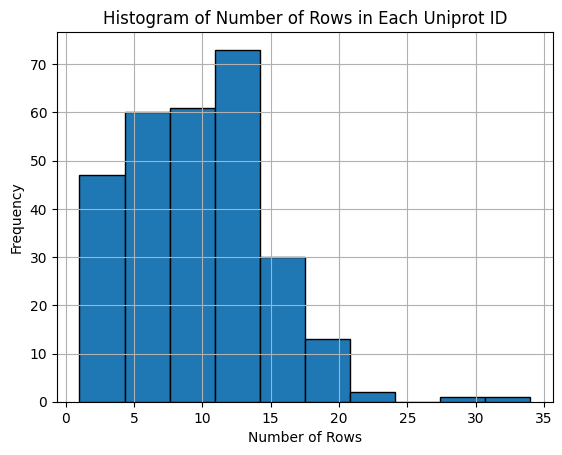

In [35]:
# calculate for each protein, how many representation sequences we got.
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Directory where the CSV files are located (change this to your directory)
directory = "data/assembly_clustered/"
# List to store the number of unique uniprot_ids
unique_uniprot_set = set()

# Dictionary to store the homology for each uniprot_id
uniprot_row_homology = {}

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.startswith("added_original_adjusted_assembly_clustered") and filename.endswith(".csv"):
        # Extract the uniprot_id from the filename
        parts = filename.split('_')
        uniprot_id = parts[-2]
        
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        
        # Check if the uniprot_id is already in the set
        if uniprot_id not in unique_uniprot_set:
            unique_uniprot_set.add(uniprot_id)
            uniprot_row_homology[uniprot_id] = set(df["uniprot_id"])
        else:
            uniprot_row_homology[uniprot_id] = uniprot_row_homology[uniprot_id]| set(df["uniprot_id"])

# Convert the row counts to a list
num_rows_list = [len(homology) for homology in uniprot_row_homology.values()]

# # Print the list of number of rows to verify
# print("Number of rows in each unique uniprot_id file:", num_rows_list)


from collections import Counter


# Calculate the frequency of each element
element_counts = Counter(num_rows_list)
# Convert Counter to dictionary
element_counts_dict = dict(element_counts)

# Sort the keys of the dictionary
sorted_keys = sorted(element_counts_dict.keys())

# Print the sorted frequency counts
for key in sorted_keys:
    print(f"{key}: {element_counts_dict[key]}")
# Print the results

print(f"mean representation sequences per protein: {np.mean(num_rows_list)} ")

# Draw a histogram of the unique uniprotid row counts
plt.hist(num_rows_list, bins=10, edgecolor='black')
plt.title('Histogram of Number of Rows in Each Uniprot ID')
plt.xlabel('Number of Rows')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Need the final list for the augmentated positive dataset

In [ ]:
# data in assembly_clustered/

In [1]:
# aggregate the csv files into a single file
import os
import pandas as pd

# Define the folder containing the CSV files
folder_path = "assembly_clustered"  # Change this to your actual folder path

# Get all CSV files in the folder that start with the specified prefix
csv_files = [f for f in os.listdir(folder_path) if f.startswith("added_original_adjusted_assembly_clustered") and f.endswith(".csv")]

# Initialize an empty list to store DataFrames
dfs = []

# Read each CSV file and append it to the list
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    dfs.append(df)

# Concatenate all DataFrames into a single DataFrame
if dfs:
    merged_df = pd.concat(dfs, ignore_index=True)

    # Save the merged DataFrame to a new CSV file
    output_file = os.path.join(folder_path, "merged_output.csv")
    merged_df.to_csv(output_file, index=False)

    print(f"Merged CSV saved as: {output_file}")
else:
    print("No matching CSV files found.")

Merged CSV saved as: assembly_clustered\merged_output.csv


In [2]:
merged_df = pd.read_csv("assembly_clustered\merged_output.csv")
merged_df

,uniprot_id,sequence,site,original_id_site
0,A0AVK6,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,396,A0AVK6_396
1,A0A8B9J405,MSSTLLNGQHLTQLPQTSPNKSAAANEKKTCVFVEPQTPGKTSGKS...,406,A0AVK6_396
2,F7EA39,MEEGSKENCGFNGSPMGSRSPPKQLTSAASVLGEIQIAAANLKTPT...,374,A0AVK6_396
3,H2UTS5,MECTSITANINPVFLRNNCDLFLTKQNLKSHFNSKTQGSYKYTKEI...,404,A0AVK6_396
4,G1KRJ4,MNTEDKENQSFEAGESTVQTPLKWTATSSSVLEEMQPAVSGRLTTP...,388,A0AVK6_396
...,...,...,...,...
3857,UPI001301B90F,MASLLMDFNAQAWRQLASPQEEGGSERRQTAPPTSQRPAAFPGSPK...,556,Q9Y6R0_324
3858,H9F0L0,MSRSAAASGGPRRPERHLPPAPCGAPGPPETCRTDPDGAGTMNKLR...,324,Q9Y6R0_324
3859,F7ETW9,MGGVCYTPGGRWAPRGLLSGRRANVGGMGRGHAAGSDVAEGRASSF...,484,Q9Y6R0_324
3860,I3N603,SGPRRPEQHLPPAPCGALGPPETFRTESDGAGTMNKLRQSLRRRKP...,247,Q9Y6R0_324


In [5]:
# for each of the sequence, use 14-3-3-Pred to get the csv file, save the csv file into a folder and record the score
# if 14-3-3-Pred extract error, record scor is nana
import os
import requests
import time

# Define the folder to save CSV files
folder_path = "assembly_clustered"  # Change this to your actual folder path

# List of UniProt IDs to download
uniprot_ids = merged_df["uniprot_id"]  # Replace with your UniProt IDs


# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Loop through each UniProt ID
for uniprot_id in uniprot_ids:

    file_path = os.path.join(folder_path, f"{uniprot_id}.csv")

    # Skip if the file already exists
    if os.path.exists(file_path):
        print(f"File {file_path} already exists. Skipping download.")
        continue

    try:
        # Format the API URL with the UniProt ID
        url = f"http://www.compbio.dundee.ac.uk/1433pred/pid={uniprot_id}&out=csv"

        # Make the request
        response = requests.get(url, timeout=10)

        # Check if request was successful
        if response.status_code == 200:
            # Save the content to a CSV file
            with open(file_path, "wb") as file:
                file.write(response.content)
            print(f"Downloaded and saved: {file_path}")
        else:
            print(f"Failed to download {uniprot_id}. HTTP Status: {response.status_code}")

    except Exception as e:
        print(f"Error downloading {uniprot_id}: {e}")

    # Small delay to avoid overwhelming the server
    time.sleep(1)

print("Download process completed.")

Download process completed.


In [27]:
import numpy as np
# merge it to the main df
merged_df = pd.read_csv("assembly_clustered\merged_output.csv")
folder_path = 'assembly_clustered'

csv_df = pd.read_csv("assembly_clustered\A0AVK6.csv")

for col in csv_df.columns:
    merged_df[col] = np.nan
    
print(merged_df.columns)


def append_csv_data_to_df(row, folder_path):
    file_name = f"{row['uniprot_id']}.csv"
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.isfile(file_path):
        # Read the CSV file into a DataFrame
        csv_df = pd.read_csv(file_path)
        
        if 'Site' not in csv_df.columns:
            return row
        
        if row['site'] == "Site is a gap":
            return row
        
        csv_df['Site'] = csv_df['Site'].astype(int)
        
        try:
            # Find the row where the 'Site' column matches the site's value from the main dataframe
            matching_row = csv_df[csv_df['Site'] == int(row['site'])]
        except Exception as e:
            print(f"Error processing file: {file_name}")
            print(f"CSV Site column: {csv_df['Site'].tolist()}, Row site: {row['site']}")
            raise e
        # print(matching_row)
        
        if not matching_row.empty:
            # Assuming you want to append all columns from the csv that aren't already in the main df
            for col in matching_row.columns:
                row[col] = matching_row.iloc[0][col]
    # print(row)
                    
    return row

# Create a new empty DataFrame to hold the results
columns = merged_df.columns.tolist()
merged_score_df = pd.DataFrame(columns=columns)

# Process each row and append the results to the new DataFrame
for index, row in merged_df.iterrows():
    new_row = append_csv_data_to_df(row, folder_path)  # Process the row with the function
    merged_score_df = merged_score_df.append(new_row, ignore_index=True)  # Append the result

Index(['uniprot_id', 'sequence', 'site', 'original_id_site', 'Site',
       'Peptide_[-6:4]', 'ANN', 'PSSM', 'SVM', 'Consensus', 'pSer/Thr'],
      dtype='object')


In [28]:
merged_score_df

,uniprot_id,sequence,site,original_id_site,Site,Peptide_[-6:4],ANN,PSSM,SVM,Consensus,pSer/Thr
0,A0AVK6,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,396,A0AVK6_396,396,NFTRHPsLIKL,0.772,0.985,0.931,0.896,-
1,A0A8B9J405,MSSTLLNGQHLTQLPQTSPNKSAAANEKKTCVFVEPQTPGKTSGKS...,406,A0AVK6_396,406,GFTRHHsLVKL,0.882,1.219,1.151,1.084,-
2,F7EA39,MEEGSKENCGFNGSPMGSRSPPKQLTSAASVLGEIQIAAANLKTPT...,374,A0AVK6_396,374,TFTRHPsLIKL,0.737,0.949,0.844,0.843,-
3,H2UTS5,MECTSITANINPVFLRNNCDLFLTKQNLKSHFNSKTQGSYKYTKEI...,404,A0AVK6_396,404,SFTRHPsLIKM,0.670,0.864,0.623,0.719,-
4,G1KRJ4,MNTEDKENQSFEAGESTVQTPLKWTATSSSVLEEMQPAVSGRLTTP...,388,A0AVK6_396,388,GFTRHPsLIKT,0.773,0.931,0.853,0.852,-
...,...,...,...,...,...,...,...,...,...,...,...
3857,UPI001301B90F,MASLLMDFNAQAWRQLASPQEEGGSERRQTAPPTSQRPAAFPGSPK...,556,Q9Y6R0_324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3858,H9F0L0,MSRSAAASGGPRRPERHLPPAPCGAPGPPETCRTDPDGAGTMNKLR...,324,Q9Y6R0_324,324,PFKRQLsLRLN,0.743,0.949,0.728,0.807,-
3859,F7ETW9,MGGVCYTPGGRWAPRGLLSGRRANVGGMGRGHAAGSDVAEGRASSF...,484,Q9Y6R0_324,484,PFKRQLsLRLN,0.743,0.949,0.728,0.807,-
3860,I3N603,SGPRRPEQHLPPAPCGALGPPETFRTESDGAGTMNKLRQSLRRRKP...,247,Q9Y6R0_324,247,PFKRQLsLRLN,0.743,0.949,0.728,0.807,-


In [29]:
merged_score_df.to_csv("assembly_clustered\merged_output_with_1433predictor_score.csv")

In [52]:
merged_score_df = pd.read_csv("assembly_clustered\merged_output_with_1433predictor_score.csv")

In [54]:
# remove sample with nan value
merged_score_df = merged_score_df.dropna()
merged_score_df["located_protein"] = merged_score_df['original_id_site'].str.split('_').str[0]
merged_score_df.to_csv("assembly_clustered\merged_output_with_1433predictor_score_dropna.csv")
merged_score_df

,Unnamed: 0,uniprot_id,sequence,site,original_id_site,Site,Peptide_[-6:4],ANN,PSSM,SVM,Consensus,pSer/Thr,located_protein
0,0,A0AVK6,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,396,A0AVK6_396,396.0,NFTRHPsLIKL,0.772,0.985,0.931,0.896,-,A0AVK6
1,1,A0A8B9J405,MSSTLLNGQHLTQLPQTSPNKSAAANEKKTCVFVEPQTPGKTSGKS...,406,A0AVK6_396,406.0,GFTRHHsLVKL,0.882,1.219,1.151,1.084,-,A0AVK6
2,2,F7EA39,MEEGSKENCGFNGSPMGSRSPPKQLTSAASVLGEIQIAAANLKTPT...,374,A0AVK6_396,374.0,TFTRHPsLIKL,0.737,0.949,0.844,0.843,-,A0AVK6
3,3,H2UTS5,MECTSITANINPVFLRNNCDLFLTKQNLKSHFNSKTQGSYKYTKEI...,404,A0AVK6_396,404.0,SFTRHPsLIKM,0.670,0.864,0.623,0.719,-,A0AVK6
4,4,G1KRJ4,MNTEDKENQSFEAGESTVQTPLKWTATSSSVLEEMQPAVSGRLTTP...,388,A0AVK6_396,388.0,GFTRHPsLIKT,0.773,0.931,0.853,0.852,-,A0AVK6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3856,3856,Q9Y6R0,MSRSAAASGGPRRPERHLPPAPCGAPGPPETCRTEPDGAGTMNKLR...,305,Q9Y6R0_305,305.0,QLVRQGsFRGF,0.530,0.775,0.228,0.511,-,Q9Y6R0
3858,3858,H9F0L0,MSRSAAASGGPRRPERHLPPAPCGAPGPPETCRTDPDGAGTMNKLR...,324,Q9Y6R0_324,324.0,PFKRQLsLRLN,0.743,0.949,0.728,0.807,-,Q9Y6R0
3859,3859,F7ETW9,MGGVCYTPGGRWAPRGLLSGRRANVGGMGRGHAAGSDVAEGRASSF...,484,Q9Y6R0_324,484.0,PFKRQLsLRLN,0.743,0.949,0.728,0.807,-,Q9Y6R0
3860,3860,I3N603,SGPRRPEQHLPPAPCGALGPPETFRTESDGAGTMNKLRQSLRRRKP...,247,Q9Y6R0_324,247.0,PFKRQLsLRLN,0.743,0.949,0.728,0.807,-,Q9Y6R0


In [55]:
group_series = merged_score_df['located_protein'].value_counts().value_counts().sort_index()

In [60]:
# unique Peptide_[-6:4] sequence
len(merged_score_df['Peptide_[-6:4]'].unique())

1803

In [56]:
for threshold in range(2,10):

    # Calculate the total samples aggregated with the specified threshold
    total_samples = sum(min(threshold, sample_count) * group_count for sample_count, group_count in group_series.items())

    print(f"Total samples aggregated with {threshold}:", total_samples)

Total samples aggregated with 2: 571
Total samples aggregated with 3: 845
Total samples aggregated with 4: 1097
Total samples aggregated with 5: 1330
Total samples aggregated with 6: 1543
Total samples aggregated with 7: 1740
Total samples aggregated with 8: 1921
Total samples aggregated with 9: 2076


In [62]:
# for the remaining, for each original sequence, select 5 top score sequence from it

# for all the uniprot id in "located_protein" 
# write a for loop
# first select all the row which have the select  uniprot id 
# then select all the row which in the "uniprot_id" column, the name is equal to uniprot id, could the select row as original_n
# for the remaining sequence, sort base on the value in "Consensus", select top (5-original_n) rows, if there is not enough row to select, then select as much as possible
# return all the select rows into a new dataframe.

# save as the positive training dataset

# Define the maximum number of sequences to select per UniProt ID
top_n = 5

# New DataFrame to store results
positive_training_dataset = pd.DataFrame()

# For each UniProt ID, filter and select sequences
for uniprot_id in set(merged_score_df["located_protein"]):
    # Filter rows belonging to the current UniProt ID
    uniprot_rows = merged_score_df[merged_score_df['located_protein'] == uniprot_id]    
    
    original_rows = merged_score_df[merged_score_df['uniprot_id'] == uniprot_id]
    
    uniprot_rows_not_in_original = uniprot_rows[~uniprot_rows['sequence'].isin(original_rows['sequence'])]

    # Count already selected sequences in 'original_id_site'
    original_n = len(original_rows)

    # Determine how many more sequences need to be selected
    remaining_to_select = max(0, top_n - original_n)

    # If still more sequences needed, sort by 'Consensus' and select top remaining_to_select rows
    if remaining_to_select > 0:
        sorted_rows = uniprot_rows_not_in_original.sort_values(by='Consensus', ascending=False)
        selected_rows = sorted_rows.head(remaining_to_select)

        # Append to the results DataFrame
        positive_training_dataset = positive_training_dataset.append(selected_rows, ignore_index=True)
        positive_training_dataset = positive_training_dataset.append(original_rows, ignore_index=True)

# Save result to a CSV file
positive_training_dataset.to_csv('assembly_clustered\positive_training_dataset.csv', index=False)

positive_training_dataset

,Unnamed: 0,uniprot_id,sequence,site,original_id_site,Site,Peptide_[-6:4],ANN,PSSM,SVM,Consensus,pSer/Thr,located_protein
0,806,H7C5C7,XVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMNKTGFVPSNYVER...,73,P16333_85,73.0,KVKRKPsVPDS,0.853,1.287,1.000,1.047,-,P16333
1,808,A0A5F9CW23,MAEEVVVVAKFDYVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMN...,85,P16333_85,85.0,KVKRKPsVPDS,0.853,1.287,1.000,1.047,-,P16333
2,810,Q5RF68,MDWLNVFKDFFSIGKVKRKPSVPDSASPADDSFVDPGERLYDLNMP...,21,P16333_85,21.0,KVKRKPsVPDS,0.853,1.287,1.000,1.047,-,P16333
3,807,H3A391,MTEEVTVIAKFDYVAQQEQELDIKKNEKLLLLDDSKSWWRVRNSMN...,85,P16333_85,85.0,KVKRKPsIRDT,0.481,0.643,0.203,0.443,-,P16333
4,811,P16333,MAEEVVVVAKFDYVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMN...,85,P16333_85,85.0,KVKRKPsVPDS,0.853,1.287,1.000,1.047,-,P16333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325,300,A0A803TYU1,MVITQTTGLSSAHSCGSLLPGSLSLKLASNSIKCWFHEGVSRQKAE...,202,O75791_262,202.0,SMSRRHtDPAQ,0.928,1.701,1.246,1.292,-,O75791
1326,297,F7BQD1,MQENVFLTRNSPLPTLEFQEQSDGTLYGLVQAPQSPAAGQMPLSRQ...,342,O75791_262,342.0,LMHRRHtDPEQ,0.922,1.692,1.218,1.277,-,O75791
1327,292,A0A8C2NU17,MVARGLGTMYQYIHLPPLSALVLLERQDFYQPHFCVFYSTMGAGHE...,197,O75791_262,197.0,LMHRRHtDPVQ,0.907,1.700,1.150,1.252,-,O75791
1328,293,A0A8C0QAV9,MEAIAKFDFTASGEDELSFHTGDVLKILSNQEEWFKAELGSQEGYV...,266,O75791_262,266.0,LMHRRHtDPVQ,0.907,1.700,1.150,1.252,-,O75791


In [64]:
len(positive_training_dataset['Peptide_[-6:4]'].unique())

888

In [11]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl.metadata (5.6 kB)
  Using cached pyparsing-3.1.4-py3-none-any.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   --------- ------------------------------ 1.8/7.5 MB 10.1 MB/s eta 0:00:01
   ---------------------- ----------------- 4.2/7.5 MB 11.0 MB/s eta 0:00:01
   ------------------------------------ --- 6.8/7.5 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 7.5/7.5 MB 11.6 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 13.6 MB/s eta 0:00:00
Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl (14.9 MB)
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 14.7 MB/s eta 0:00:00
Using cached pypar

  You can safely remove it manually.


### 4.2	Balanced Negative Sampling Framework

Task 33: As mentioned previously, the original dataset curated from the literature exhibits a significant bias towards known 14-3-3 binding proteins. As a result, models built using this dataset are not suitable for generalizing to the entire human proteome. To address this, we propose a negative data sampling strategy to enhance the negative data. First, we calculate scores for protein length, intrinsic disorder region (IDR), anchor_score and phosphorylation features using the human proteome. Then, we bin and plot the distribution of these multi-scale features. By comparing the distribution of the entire proteome to that of the 14-3-3 binding proteins, we observe that our dataset does not represent the overall distribution of the human proteome.

In [1]:
import pandas as pd
# get the length of the protein
# protein_lengths_df = pd.read_csv("data/protein_lengths.csv")
protein_lengths_df = pd.read_csv("protein_lengths.csv")
protein_lengths_df.head(2)

,UniProt ID,Protein Length
0,A0A087X1C5,515
1,A0A0B4J2F0,54


In [2]:
protein_length_dict = protein_lengths_df.set_index('UniProt ID')['Protein Length'].to_dict()
print(len(protein_length_dict))

20426


In [3]:
# get the whole proteome IDR(IUPred2A) data
# get the whole proteome ANCHOR2 score data
# protein_lengths_df = pd.read_csv('data/collected_st_amino_acids_idrscore_anchorscore.csv')
protein_idr_df = pd.read_csv('collected_st_amino_acids_idrscore_anchorscore.csv')
protein_idr_df.columns = ['uniqueid', 'position', 'amino_acid', 'iupred_score', 'anchor_score']
protein_idr_df['uniprot_id'] = protein_idr_df['uniqueid'].str.split('_', expand=True)[0]
protein_idr_df['prot_id_position'] = protein_idr_df['uniprot_id'] + "_" + protein_idr_df['position'].astype(str)
protein_idr_df.head(2)

,uniqueid,position,amino_acid,iupred_score,anchor_score,uniprot_id,prot_id_position
0,Q8NGF9_T_2,2,T,0.003177,0.000058,Q8NGF9,Q8NGF9_2
1,Q8NGF9_S_10,10,S,0.004483,0.000058,Q8NGF9,Q8NGF9_10


In [4]:
# get the whole proteome phosphorylation score data
import os
phospholingo_file_path = "preds_swissprot_ST.csv"
current_directory = os.getcwd()
full_path = os.path.join(current_directory, phospholingo_file_path)
df_phospholingo_score = pd.read_csv(full_path)
df_phospholingo_score["prot_id_position"] = df_phospholingo_score["prot_id"] + "_" + df_phospholingo_score["position"].astype(str)
df_phospholingo_score.columns = ['prot_id', 'position_x', 'phospho_score', 'prot_id_position']
df_phospholingo_score.head(2)

,prot_id,position_x,phospho_score,prot_id_position
0,A0A087X1C5,54,0.051,A0A087X1C5_54
1,A0A087X1C5,70,0.039,A0A087X1C5_70


In [5]:
# merge df
merged_df = pd.merge(protein_idr_df, df_phospholingo_score, on='prot_id_position', how='inner')
merged_df["protein_length"] = merged_df["prot_id"].map(protein_length_dict)
merged_df = merged_df[['uniqueid', 'uniprot_id', "position", 'prot_id_position', 'protein_length', 'iupred_score', 'anchor_score', 'phospho_score']]
merged_df = merged_df.dropna()
merged_df = merged_df[(merged_df['protein_length'] < 4800)&(merged_df['protein_length'] > 100)]
merged_df.head(2)

,uniqueid,uniprot_id,position,prot_id_position,protein_length,iupred_score,anchor_score,phospho_score
0,P62241_S_4,P62241,4,P62241_4,208,0.566480,0.756483,0.523
1,P62241_T_14,P62241,14,P62241_14,208,0.745909,0.756483,0.641


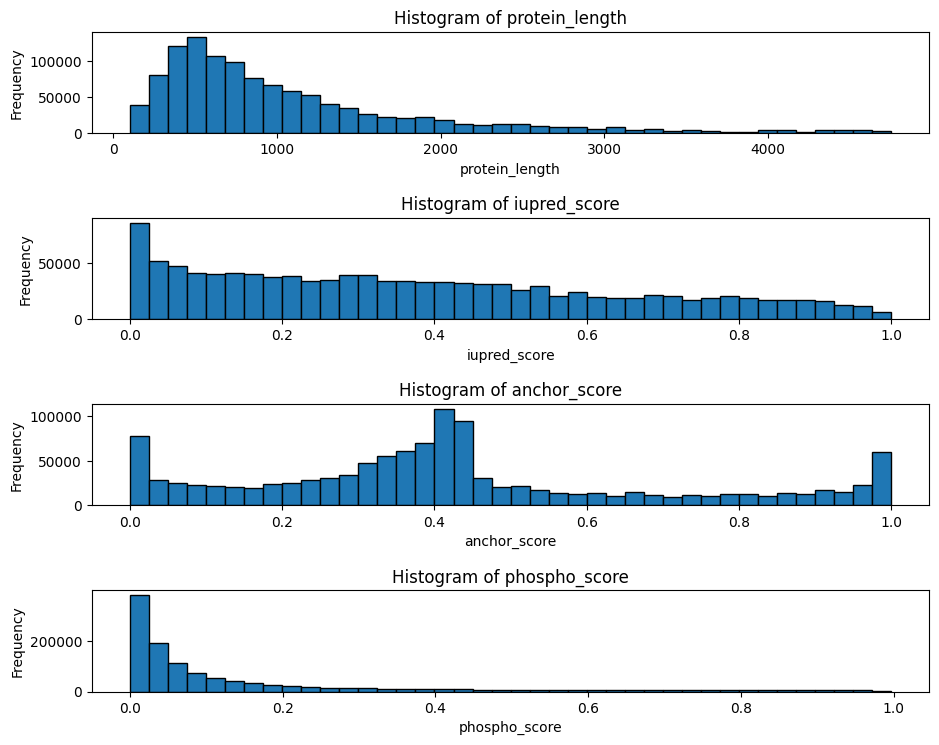

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
# Columns to plot
columns_to_plot = ['protein_length', 'iupred_score', 'anchor_score', 'phospho_score']

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(10, 8))
fig.tight_layout(pad=4.0)  # Add spacing between plots

# Plot each histogram in a subplot
for i, column in enumerate(columns_to_plot):
    merged_df[column].plot(kind='hist', bins=40, edgecolor='black', ax=axes[i])
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Display the plots
plt.show()

In [7]:
# processing known negative sample point in
curated_dataset_df = pd.read_csv("Table 1.csv")
curated_dataset_df = curated_dataset_df[curated_dataset_df["label"]==0]
curated_dataset_df["prot_id_position"] = curated_dataset_df["human homology accession"] + "_" + curated_dataset_df["human homology site without letter"].astype(str)
curated_dataset_negative_dict = curated_dataset_df["prot_id_position"]
print(curated_dataset_negative_dict)

350    O14757_345
351    Q53ET0_244
352     P14136_13
353     P05783_51
354    Q7Z418_264
          ...    
940    O75385_660
941    P40818_718
942    P46937_109
943    P26651_197
944    P26651_186
Name: prot_id_position, Length: 489, dtype: object


In [8]:
df_labeled_negative = merged_df[merged_df["prot_id_position"].isin(curated_dataset_negative_dict)]

In [9]:
length_num_bins = 2  # Define the number of bins for protein length
idr_num_bins = 2  # Define the number of bins for idr
anchor_num_bins = 4 # Define the number of bins for anchor
phospho_num_bins = 2  # Define the number of bins for phosphorylation

In [10]:
merged_df.head(2)

,uniqueid,uniprot_id,position,prot_id_position,protein_length,iupred_score,anchor_score,phospho_score
0,P62241_S_4,P62241,4,P62241_4,208,0.566480,0.756483,0.523
1,P62241_T_14,P62241,14,P62241_14,208,0.745909,0.756483,0.641


In [11]:
def bin_feature(df, length_num_bins, idr_num_bins, anchor_num_bins, phospho_num_bins):
    df = df.copy()
    df['binned_protein_length'] = pd.cut(df['protein_length'], bins=length_num_bins, labels=False)
    df['binned_iupred_score'] = pd.cut(df['iupred_score'], bins=idr_num_bins, labels=False)
    df['binned_anchor_score'] = pd.cut(df['anchor_score'], bins=anchor_num_bins, labels=False)
    df['binned_phospho_score'] = pd.cut(df['phospho_score'], bins=phospho_num_bins, labels=False)
    df['stratification_label'] = df['binned_protein_length'].astype(str) + "_" + df['binned_iupred_score'].astype(str) + "_" + df['binned_anchor_score'].astype(str) +"_" + df['binned_phospho_score'].astype(str)
    return df

In [12]:
df = bin_feature(merged_df, length_num_bins, idr_num_bins, anchor_num_bins, phospho_num_bins)

In [13]:
df.head()

,uniqueid,uniprot_id,position,prot_id_position,protein_length,iupred_score,anchor_score,phospho_score,binned_protein_length,binned_iupred_score,binned_anchor_score,binned_phospho_score,stratification_label
0,P62241_S_4,P62241,4,P62241_4,208,0.566480,0.756483,0.523,0,1,3,1,0_1_3_1
1,P62241_T_14,P62241,14,P62241_14,208,0.745909,0.756483,0.641,0,1,3,1,0_1_3_1
2,P62241_T_36,P62241,36,P62241_36,208,0.476583,0.756483,0.247,0,0,3,0,0_0_3_0
3,P62241_T_45,P62241,45,P62241_45,208,0.566480,0.756483,0.359,0,1,3,0,0_1_3_0
4,P62241_S_66,P62241,66,P62241_66,208,0.264545,0.756483,0.710,0,0,3,1,0_0_3_1


In [14]:
df_values = df['stratification_label'].value_counts(normalize=True)
categories = list(df_values.index)

In [15]:
df_labeled_negative = bin_feature(df_labeled_negative, length_num_bins, idr_num_bins, anchor_num_bins, phospho_num_bins)
df_labeled_negative_values = df_labeled_negative['stratification_label'].value_counts(normalize=True).reindex(categories)

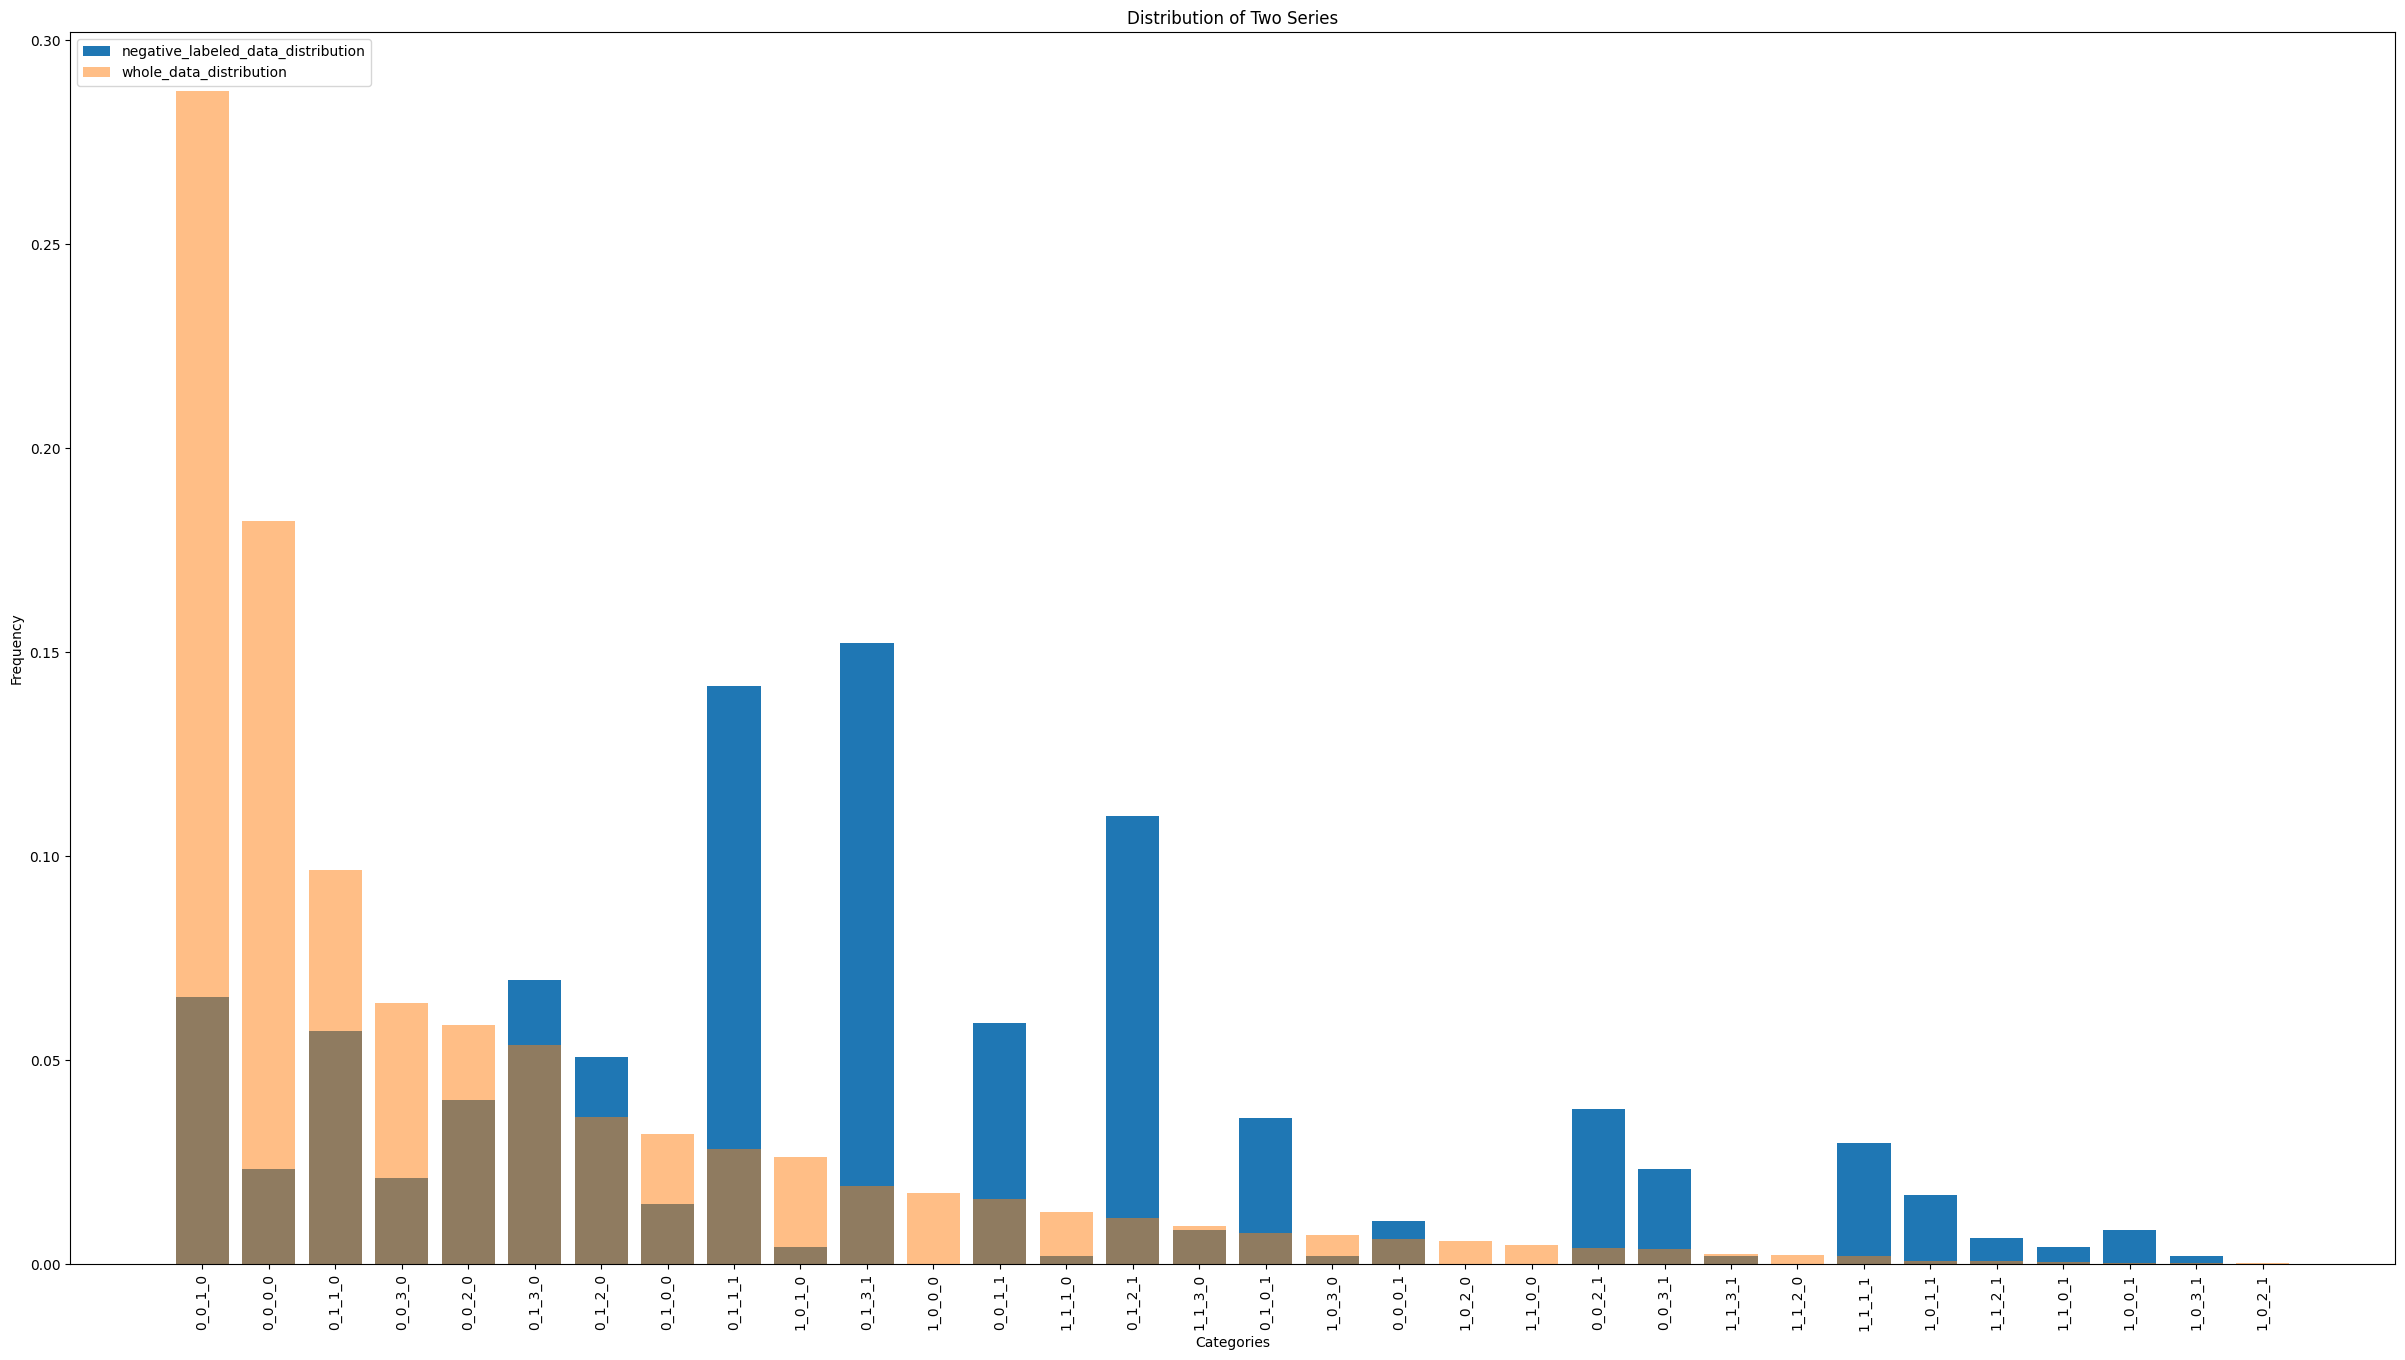

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 16)) 

# Plot the distribution of the first series
plt.bar(df_labeled_negative_values.index, df_labeled_negative_values.values, label='negative_labeled_data_distribution')

# Plot the distribution of the second series on the same plot
plt.bar(df_values.index, df_values.values, alpha=0.5, label='whole_data_distribution')

plt.xticks(rotation=90)
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.title('Distribution of Two Series')
plt.legend()
plt.show()

Task 34: We sampled data points from all serine (S) and threonine (T) sites in the human proteome to ensure that the negative sample distribution closely matches the entire human proteome distribution. 

In [17]:
# calculate the sample size
# with Confidence Level: 99%, Margin of Error: 2.5%, Population Size:1200000
# 2657 sample size is needed
sample_size = 2657

In [18]:
import pandas as pd
import numpy as np
# calculate the sample size for each straum
df_stratum_sample_size = df_values * sample_size
df_stratum_sample_size_ceil = np.ceil(df_stratum_sample_size).astype(int)
df_stratum_sample_size_ceil

stratification_label
0_0_1_0    765
0_0_0_0    484
0_1_1_0    257
0_0_3_0    171
0_0_2_0    156
0_1_3_0    144
0_1_2_0     96
0_1_0_0     85
0_1_1_1     75
1_0_1_0     70
0_1_3_1     52
1_0_0_0     47
0_0_1_1     43
1_1_1_0     35
0_1_2_1     30
1_1_3_0     25
0_1_0_1     21
1_0_3_0     19
0_0_0_1     17
1_0_2_0     16
1_1_0_0     13
0_0_2_1     11
0_0_3_1     11
1_1_3_1      7
1_1_2_0      7
1_1_1_1      6
1_0_1_1      3
1_1_2_1      2
1_1_0_1      2
1_0_0_1      1
1_0_3_1      1
1_0_2_1      1
Name: proportion, dtype: int32

In [19]:
df_labeled_negative_values_stratum = df_labeled_negative['stratification_label'].value_counts()
df_labeled_negative_values_stratum = df_labeled_negative_values_stratum.reindex(df_stratum_sample_size_ceil.index, fill_value=0)
df_labeled_negative_values_stratum

stratification_label
0_0_1_0    31
0_0_0_0    11
0_1_1_0    27
0_0_3_0    10
0_0_2_0    19
0_1_3_0    33
0_1_2_0    24
0_1_0_0     7
0_1_1_1    67
1_0_1_0     2
0_1_3_1    72
1_0_0_0     0
0_0_1_1    28
1_1_1_0     1
0_1_2_1    52
1_1_3_0     4
0_1_0_1    17
1_0_3_0     1
0_0_0_1     5
1_0_2_0     0
1_1_0_0     0
0_0_2_1    18
0_0_3_1    11
1_1_3_1     1
1_1_2_0     0
1_1_1_1    14
1_0_1_1     8
1_1_2_1     3
1_1_0_1     2
1_0_0_1     4
1_0_3_1     1
1_0_2_1     0
Name: count, dtype: int64

In [20]:
stratum_sample_size = df_stratum_sample_size_ceil.sub(df_labeled_negative_values_stratum, axis='index')
stratum_sample_size

stratification_label
0_0_1_0    734
0_0_0_0    473
0_1_1_0    230
0_0_3_0    161
0_0_2_0    137
0_1_3_0    111
0_1_2_0     72
0_1_0_0     78
0_1_1_1      8
1_0_1_0     68
0_1_3_1    -20
1_0_0_0     47
0_0_1_1     15
1_1_1_0     34
0_1_2_1    -22
1_1_3_0     21
0_1_0_1      4
1_0_3_0     18
0_0_0_1     12
1_0_2_0     16
1_1_0_0     13
0_0_2_1     -7
0_0_3_1      0
1_1_3_1      6
1_1_2_0      7
1_1_1_1     -8
1_0_1_1     -5
1_1_2_1     -1
1_1_0_1      0
1_0_0_1     -3
1_0_3_1      0
1_0_2_1      1
dtype: int64

### Establish the Sampling Criteria

In [27]:
# not sample from 14-3-3 interaction protein and heart 14-3-3 ms/ms interaction dataset
# not sample from the protein which is in the labeled group (both positive and negative)
# not sample if the length of the protein is larger than 4800 (done when process the merged_df df)

In [28]:
# not sample from 14-3-3 interaction protein and heart 14-3-3 ms/ms interaction dataset

# download protein protein interaction dataset from Biogrid
# Read the tab-separated file into a DataFrame

file_path = "data/BIOGRID-ALL-4.4.237.mitab.zip"

biogrid = pd.read_csv(file_path, delimiter='\t', encoding='utf-8')

# Display the DataFrame
biogrid.head(2)

# select all the interaction happening between human proteins
biogrid = biogrid[(biogrid['Taxid Interactor A'] == "taxid:9606")&(biogrid['Taxid Interactor B'] == "taxid:9606")]
import pandas as pd
import re
def extract_and_clean_uniprot_id(text):
    # Regex pattern to match 'uniprot/swiss-prot:P45985'
    match = re.search(r'uniprot/swiss-prot:([\w\d]+)', text)
    return match.group(1) if match else None
# Apply the function to the DataFrame columns

biogrid['Uniprot ID A'] = biogrid['Alt IDs Interactor A'].apply(extract_and_clean_uniprot_id)
biogrid['Uniprot ID B'] = biogrid['Alt IDs Interactor B'].apply(extract_and_clean_uniprot_id)
biogrid_interactions = biogrid[['Uniprot ID A','Uniprot ID B']]
biogrid_interactions.head(2)

Protins_1433 = ["P62258", "P27348", "Q04917", "P61981", "P31946", "P31947", "P63104"]
Protein_1433_interactome_df = biogrid_interactions[biogrid_interactions["Uniprot ID A"].isin(Protins_1433)]
interaction_with_1433_set = set(Protein_1433_interactome_df["Uniprot ID B"])
len(interaction_with_1433_set)

FileNotFoundError: [Errno 2] No such file or directory: 'BIOGRID-ALL-4.4.237.mitab.zip'

In [ ]:
# can not sample from heart 14-3-3 ms/ms interaction dataset, the data is from mouse, can not use it

In [ ]:
# not sample from the protein which is in the labeled group (both positive and negative)
import pandas as pd
# for each uniprot id in table1, find all the homologies and save it into a list
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df = curated_dataset_df[curated_dataset_df["label"]==1]
curated_dataset_df
df_labeled_set = set(curated_dataset_df["human homology accession"])
len(df_labeled_set)
len(df_labeled_set.union(interaction_with_1433_set))

In [ ]:
total_not_sample_set = df_labeled_set.union(interaction_with_1433_set)
len(total_not_sample_set)

In [23]:
df.head(2)

,uniqueid,uniprot_id,position,prot_id_position,protein_length,iupred_score,anchor_score,phospho_score,binned_protein_length,binned_iupred_score,binned_anchor_score,binned_phospho_score,stratification_label
0,P62241_S_4,P62241,4,P62241_4,208,0.566480,0.756483,0.523,0,1,3,1,0_1_3_1
1,P62241_T_14,P62241,14,P62241_14,208,0.745909,0.756483,0.641,0,1,3,1,0_1_3_1


In [24]:
sampling_df = df[~df["uniprot_id"].isin(total_not_sample_set)]
sampling_df

NameError: name 'total_not_sample_set' is not defined

In [25]:
whole_sampled_df = pd.DataFrame()
used_uniprot_lst = list(df_labeled_negative["uniprot_id"])
for index, value in stratum_sample_size.items():
    if value >0:
        df_tmp = sampling_df[sampling_df["stratification_label"] == index]
        df_tmp = df_tmp[~df_tmp["uniprot_id"].isin(set(used_uniprot_lst))]
        # sampled_df = df_tmp.sample(n=value,random_state=42)
        
        # Sample one row per unique 'uniprot_id'
        unique_sampled_df = df_tmp.groupby("uniprot_id").sample(n=1, random_state=42)
        
        # Adjust the sample size if necessary
        value = min(value, len(unique_sampled_df))  # Ensure value does not exceed available rows
        
        # Sample the desired number of rows
        sampled_df = unique_sampled_df.sample(n=value, random_state=42)
        
        if len(whole_sampled_df) == 0:
            whole_sampled_df = sampled_df
        else:
            whole_sampled_df = pd.concat([whole_sampled_df, sampled_df], axis=0)
        used_uniprot_lst = used_uniprot_lst + list(sampled_df["uniprot_id"])

NameError: name 'sampling_df' is not defined

In [ ]:
whole_sampled_df["label"] = 0
whole_sampled_df["augmentated data?"] = 1
whole_sampled_df["homology data?"] = 0
whole_sampled_df

In [ ]:
whole_sampled_df = whole_sampled_df.drop_duplicates(subset='uniprot_id')
whole_sampled_df

In [ ]:
df_labeled_negative["label"] = 0
df_labeled_negative["augmentated data?"] = 0
df_labeled_negative["homology data?"] = 0
df_labeled_negative

In [ ]:
labeled_and_augmented_data = pd.concat([whole_sampled_df, df_labeled_negative], axis=0)
labeled_and_augmented_data.reset_index(inplace = True)

In [ ]:
labeled_and_augmented_data["label"].value_counts()

In [ ]:
labeled_and_augmented_data_without_duplicates = labeled_and_augmented_data.drop_duplicates()
labeled_and_augmented_data_without_duplicates

In [ ]:
labeled_and_augmented_data_without_duplicates.to_csv("labeled_and_augmented_negative_data.csv")

In [ ]:
df_labeled_negative_values = labeled_and_augmented_data_without_duplicates['stratification_label'].value_counts(normalize=True).reindex(categories)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 16)) 

# Plot the distribution of the first series
plt.bar(df_labeled_negative_values.index, df_labeled_negative_values.values, label='negative_labeled_data_distribution')

# Plot the distribution of the second series on the same plot
plt.bar(df_values.index, df_values.values, alpha=0.5, label='whole_data_distribution')

plt.xticks(rotation=90)
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.title('Distribution of Two Series')
plt.legend()
plt.show()

Task 35: After sampling, we observed that the distribution of protein length, condensation, IDR, and phosphorylation features now aligns with the overall protein distribution, with no significant differences.

In [ ]:
labeled_negative_distribution = df_labeled_negative_values.values
labeled_negative_distribution

In [18]:
whole_distribution = df_values.values
whole_distribution

NameError: name 'df_values' is not defined

In [19]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.DataFrame({
    "labeled_negative_distribution": labeled_negative_distribution,
    "whole_distribution": whole_distribution
})

contingency_table_filled = contingency_table.fillna(0)

# Perform the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table_filled)

# Output the results
print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies Table:")
print(expected)

# Determine whether to reject the null hypothesis
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The distributions are significantly different.")
else:
    print("Fail to reject the null hypothesis: The distributions are not significantly different.")

NameError: name 'labeled_negative_distribution' is not defined